<a href="https://colab.research.google.com/github/praneethk002/AM11_Individual_Assignment/blob/main/ML_Final_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Setup & Data Collection


In [ ]:
!pip install fredapi

In [ ]:
import pandas as pd
import numpy as np
from fredapi.fred import Fred
import os
np.random.seed(42)

In [ ]:
#FRED DATA FOR YIELD SETUP
from google.colab import userdata
api_key = userdata.get('FRED_API_KEY')
fred = Fred(api_key)

In [ ]:
series_ids = ['DGS2', 'DGS5', 'DGS10', 'DGS30', 'T10Y2Y']
df_yields_list = []

In [ ]:
series_ids = ['DGS2', 'DGS5', 'DGS10', 'DGS30', 'T10Y2Y']
yield_series_dict = {}

for series_id in series_ids:
    # Fetch data for each series.
    # observation_start and observation_end can help filter the initial fetch.
    series_data = fred.get_series(series_id, observation_start='2000-01-01', observation_end=None)
    if series_data is not None and not series_data.empty:
        # Store each series in a dictionary with its series_id as the key
        yield_series_dict[series_id] = series_data

# Concatenate all fetched series into a single DataFrame using the dictionary
if yield_series_dict:
    df_yields = pd.DataFrame(yield_series_dict)

    # Resample to monthly and take the last business day of the month as per spec
    # Using 'ME' for month-end frequency, for consistency with yfinance and modern pandas.
    df_yields = df_yields.resample('ME').last()

    # Filter to the specified date range 2000-2025
    df_yields = df_yields[(df_yields.index.year >= 2000)]

    # The spec states "No NaNs in the core period".
    # For now, we will drop rows that are entirely NaN, which might happen at boundaries.
    # More sophisticated NaN handling (e.g., forward fill, interpolation) might be needed
    # depending on what "core period" means for NaN absence.
    df_yields = df_yields.dropna(how='all')

    print("df_yields head:")
    print(df_yields.head())
    print("\ndf_yields info:")
    print(df_yields.info())
else:
    df_yields = pd.DataFrame()
    print("No data fetched for the specified series. Check API key and series IDs.")

df_yields head:
            DGS2  DGS5  DGS10  DGS30  T10Y2Y
2000-01-31  6.61  6.71   6.68   6.49    0.07
2000-02-29  6.53  6.61   6.42   6.15   -0.11
2000-03-31  6.50  6.32   6.03   5.84   -0.47
2000-04-30  6.68  6.56   6.23   5.97   -0.45
2000-05-31  6.69  6.54   6.29   6.02   -0.40

df_yields info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 316 entries, 2000-01-31 to 2026-04-30
Freq: ME
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DGS2    316 non-null    float64
 1   DGS5    316 non-null    float64
 2   DGS10   316 non-null    float64
 3   DGS30   316 non-null    float64
 4   T10Y2Y  316 non-null    float64
dtypes: float64(5)
memory usage: 14.8 KB
None


In [ ]:
df_yields

,DGS2,DGS5,DGS10,DGS30,T10Y2Y
2000-01-31,6.61,6.71,6.68,6.49,0.07
2000-02-29,6.53,6.61,6.42,6.15,-0.11
2000-03-31,6.50,6.32,6.03,5.84,-0.47
2000-04-30,6.68,6.56,6.23,5.97,-0.45
2000-05-31,6.69,6.54,6.29,6.02,-0.40
...,...,...,...,...,...
2025-12-31,3.47,3.73,4.18,4.84,0.71
2026-01-31,3.52,3.79,4.26,4.87,0.74
2026-02-28,3.38,3.51,3.97,4.64,0.59
2026-03-31,3.79,3.92,4.30,4.88,0.51


In [ ]:
df_yields.dropna(how='all')

,DGS2,DGS5,DGS10,DGS30,T10Y2Y
2000-01-31,6.61,6.71,6.68,6.49,0.07
2000-02-29,6.53,6.61,6.42,6.15,-0.11
2000-03-31,6.50,6.32,6.03,5.84,-0.47
2000-04-30,6.68,6.56,6.23,5.97,-0.45
2000-05-31,6.69,6.54,6.29,6.02,-0.40
...,...,...,...,...,...
2025-12-31,3.47,3.73,4.18,4.84,0.71
2026-01-31,3.52,3.79,4.26,4.87,0.74
2026-02-28,3.38,3.51,3.97,4.64,0.59
2026-03-31,3.79,3.92,4.30,4.88,0.51


In [ ]:
import yfinance as yf
import pandas as pd

# Define the list of ticker symbols for the sector ETFs and SPY
sector_tickers = ['XLF', 'XLE', 'XLK', 'XLU', 'XLP', 'XLY', 'XLV', 'XLI', 'XLB', 'SPY']


# Fetch monthly adjusted close prices from Yahoo Finance
# Setting the start date slightly before 2000-01-01 to ensure the first month's return (Jan 2000) can be calculated.
# Explicitly set auto_adjust=False to ensure 'Adj Close' column is available.
data = yf.download(sector_tickers, start='1999-12-01', end= None, interval='1mo', auto_adjust=False)

# Extract only the 'Adj Close' prices for all tickers
adj_close_prices = data['Adj Close']

# Convert index to month-end dates for proper alignment with df_yields.
# yfinance with '1mo' interval typically returns dates as the first day of the month.
adj_close_prices.index = adj_close_prices.index + pd.offsets.MonthEnd(0)

# Calculate monthly returns (percentage change).
# Keeping returns as decimals internally; they can be multiplied by 100 for display if needed.
df_sectors = adj_close_prices.pct_change()

# Drop the first row which will contain NaN values due to pct_change() (the return for the first month fetched).
df_sectors = df_sectors.dropna()

# Filter to the specified date range 2000-2025.
df_sectors = df_sectors[(df_sectors.index.year >= 2000) ]

# Ensure the index is a DatetimeIndex and its frequency is explicitly set to 'ME' (Month End).
# This helps ensure consistency with df_yields.
df_sectors = df_sectors.asfreq('ME')

print("df_sectors head:")
print(df_sectors.head())
print("\ndf_sectors info:")
print(df_sectors.info())

[*********************100%***********************]  10 of 10 completed

df_sectors head:
Ticker           SPY       XLB       XLE       XLF       XLI       XLK  \
Date                                                                     
2000-01-31 -0.047455 -0.118590  0.011048 -0.026024 -0.078157 -0.061466   
2000-02-29 -0.015226 -0.100469 -0.042334 -0.107046 -0.055173  0.105068   
2000-03-31  0.094134  0.098288  0.120669  0.178300  0.136862  0.083893   
2000-04-30 -0.032668 -0.030927 -0.011625  0.013363  0.016539 -0.091847   
2000-05-31 -0.015723 -0.031556  0.117424  0.022321 -0.004220 -0.103977   

Ticker           XLP       XLU       XLV       XLY  
Date                                                
2000-01-31  0.011767 -0.011503 -0.019587 -0.123148  
2000-02-29 -0.117014 -0.121538 -0.065386 -0.055715  
2000-03-31  0.034272  0.101030  0.089950  0.139294  
2000-04-30  0.056400  0.073402 -0.011716 -0.018912  
2000-05-31  0.071329 -0.002195 -0.026804 -0.053980  

df_sectors info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 316 entries, 2000-01-3

In [ ]:
df_sectors

Ticker,SPY,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,,
2000-01-31,-0.047455,-0.118590,0.011048,-0.026024,-0.078157,-0.061466,0.011767,-0.011503,-0.019587,-0.123148
2000-02-29,-0.015226,-0.100469,-0.042334,-0.107046,-0.055173,0.105068,-0.117014,-0.121538,-0.065386,-0.055715
2000-03-31,0.094134,0.098288,0.120669,0.178300,0.136862,0.083893,0.034272,0.101030,0.089950,0.139294
2000-04-30,-0.032668,-0.030927,-0.011625,0.013363,0.016539,-0.091847,0.056400,0.073402,-0.011716,-0.018912
2000-05-31,-0.015723,-0.031556,0.117424,0.022321,-0.004220,-0.103977,0.071329,-0.002195,-0.026804,-0.053980
...,...,...,...,...,...,...,...,...,...,...
2025-12-31,-0.002151,0.014541,-0.011388,0.027002,0.009304,0.006009,-0.021293,-0.057928,-0.018078,0.009981
2026-01-31,0.017736,0.092047,0.151536,-0.020873,0.070182,0.000891,0.083676,0.020708,0.003869,0.016750
2026-02-28,-0.008642,0.084027,0.095397,-0.037612,0.070720,-0.035585,0.077835,0.103584,0.035285,-0.035570


In [ ]:
print(f"Shape of df_yields: {df_yields.shape}")
print(f"Shape of df_sectors: {df_sectors.shape}")

if df_yields.shape[0] == df_sectors.shape[0]:
    print("Both DataFrames have the same number of rows.")
else:
    print("Warning: DataFrames have different numbers of rows. Check alignment.")


Shape of df_yields: (316, 5)
Shape of df_sectors: (316, 10)
Both DataFrames have the same number of rows.


In [ ]:
print("Missing values in df_yields:")
print(df_yields.isnull().sum())

Missing values in df_yields:
DGS2      0
DGS5      0
DGS10     0
DGS30     0
T10Y2Y    0
dtype: int64


In [ ]:
print(df_yields.index.equals(df_sectors.index))
print(df_sectors.isnull().sum())

True
Ticker
SPY    0
XLB    0
XLE    0
XLF    0
XLI    0
XLK    0
XLP    0
XLU    0
XLV    0
XLY    0
dtype: int64


Visualize the `T10Y2Y` spread to check for yield curve inversions and `XLF` monthly returns to observe the 2008 crash.

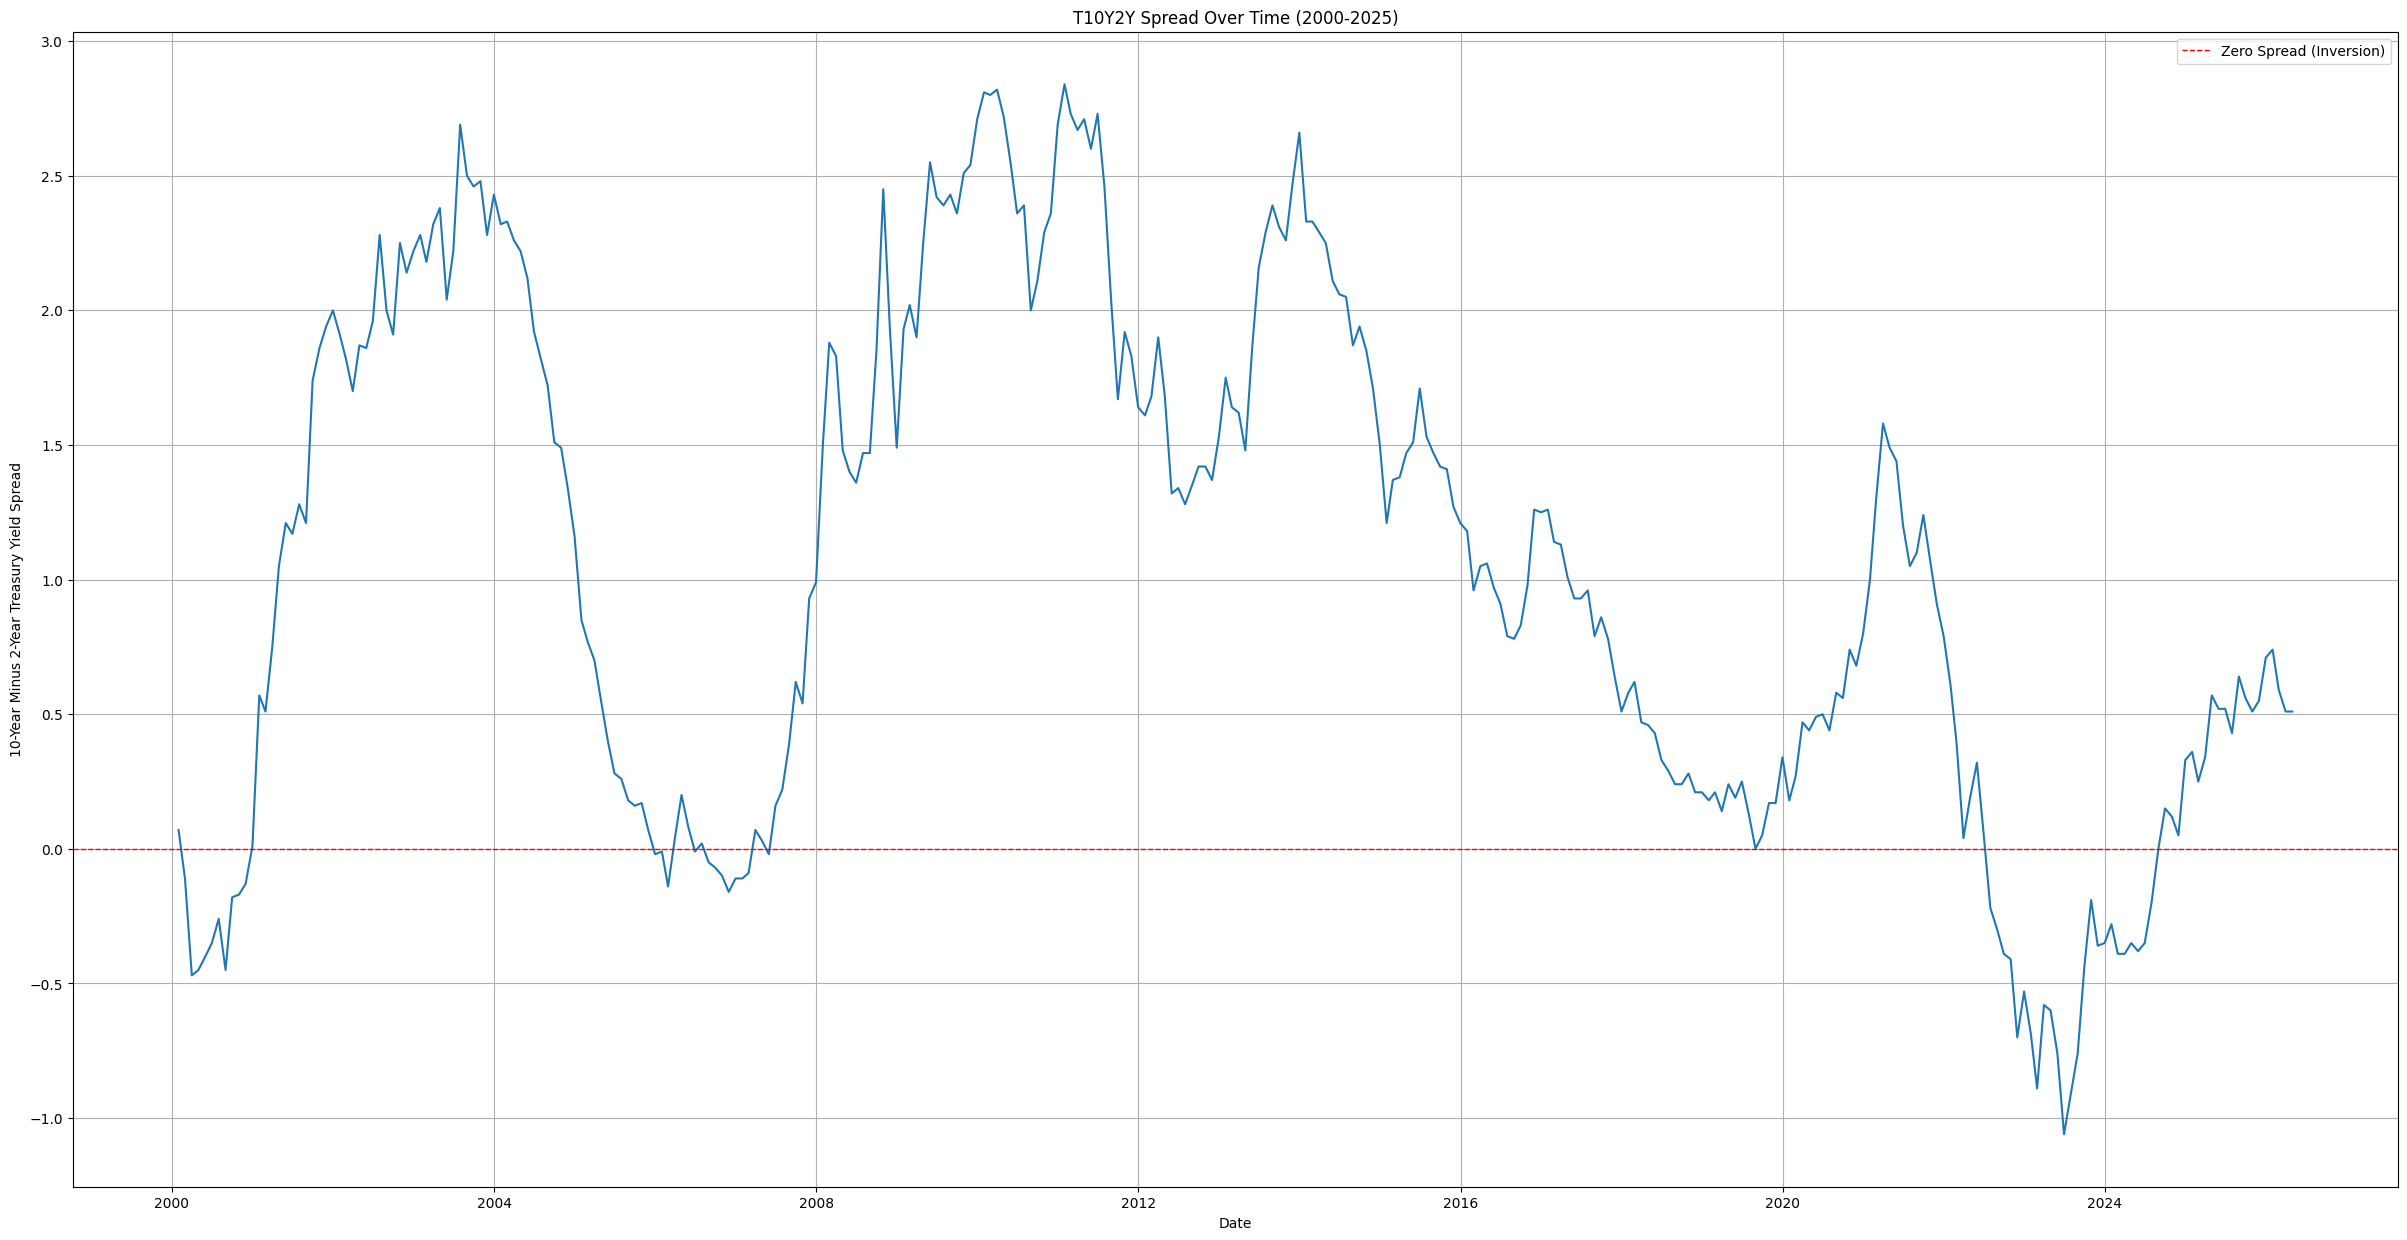

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(30, 15))
sns.lineplot(x=df_yields.index, y=df_yields['T10Y2Y'])
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Spread (Inversion)')
plt.title('T10Y2Y Spread Over Time (2000-2025)')
plt.xlabel('Date')
plt.ylabel('10-Year Minus 2-Year Treasury Yield Spread')
plt.grid(True)
plt.legend()
plt.show()

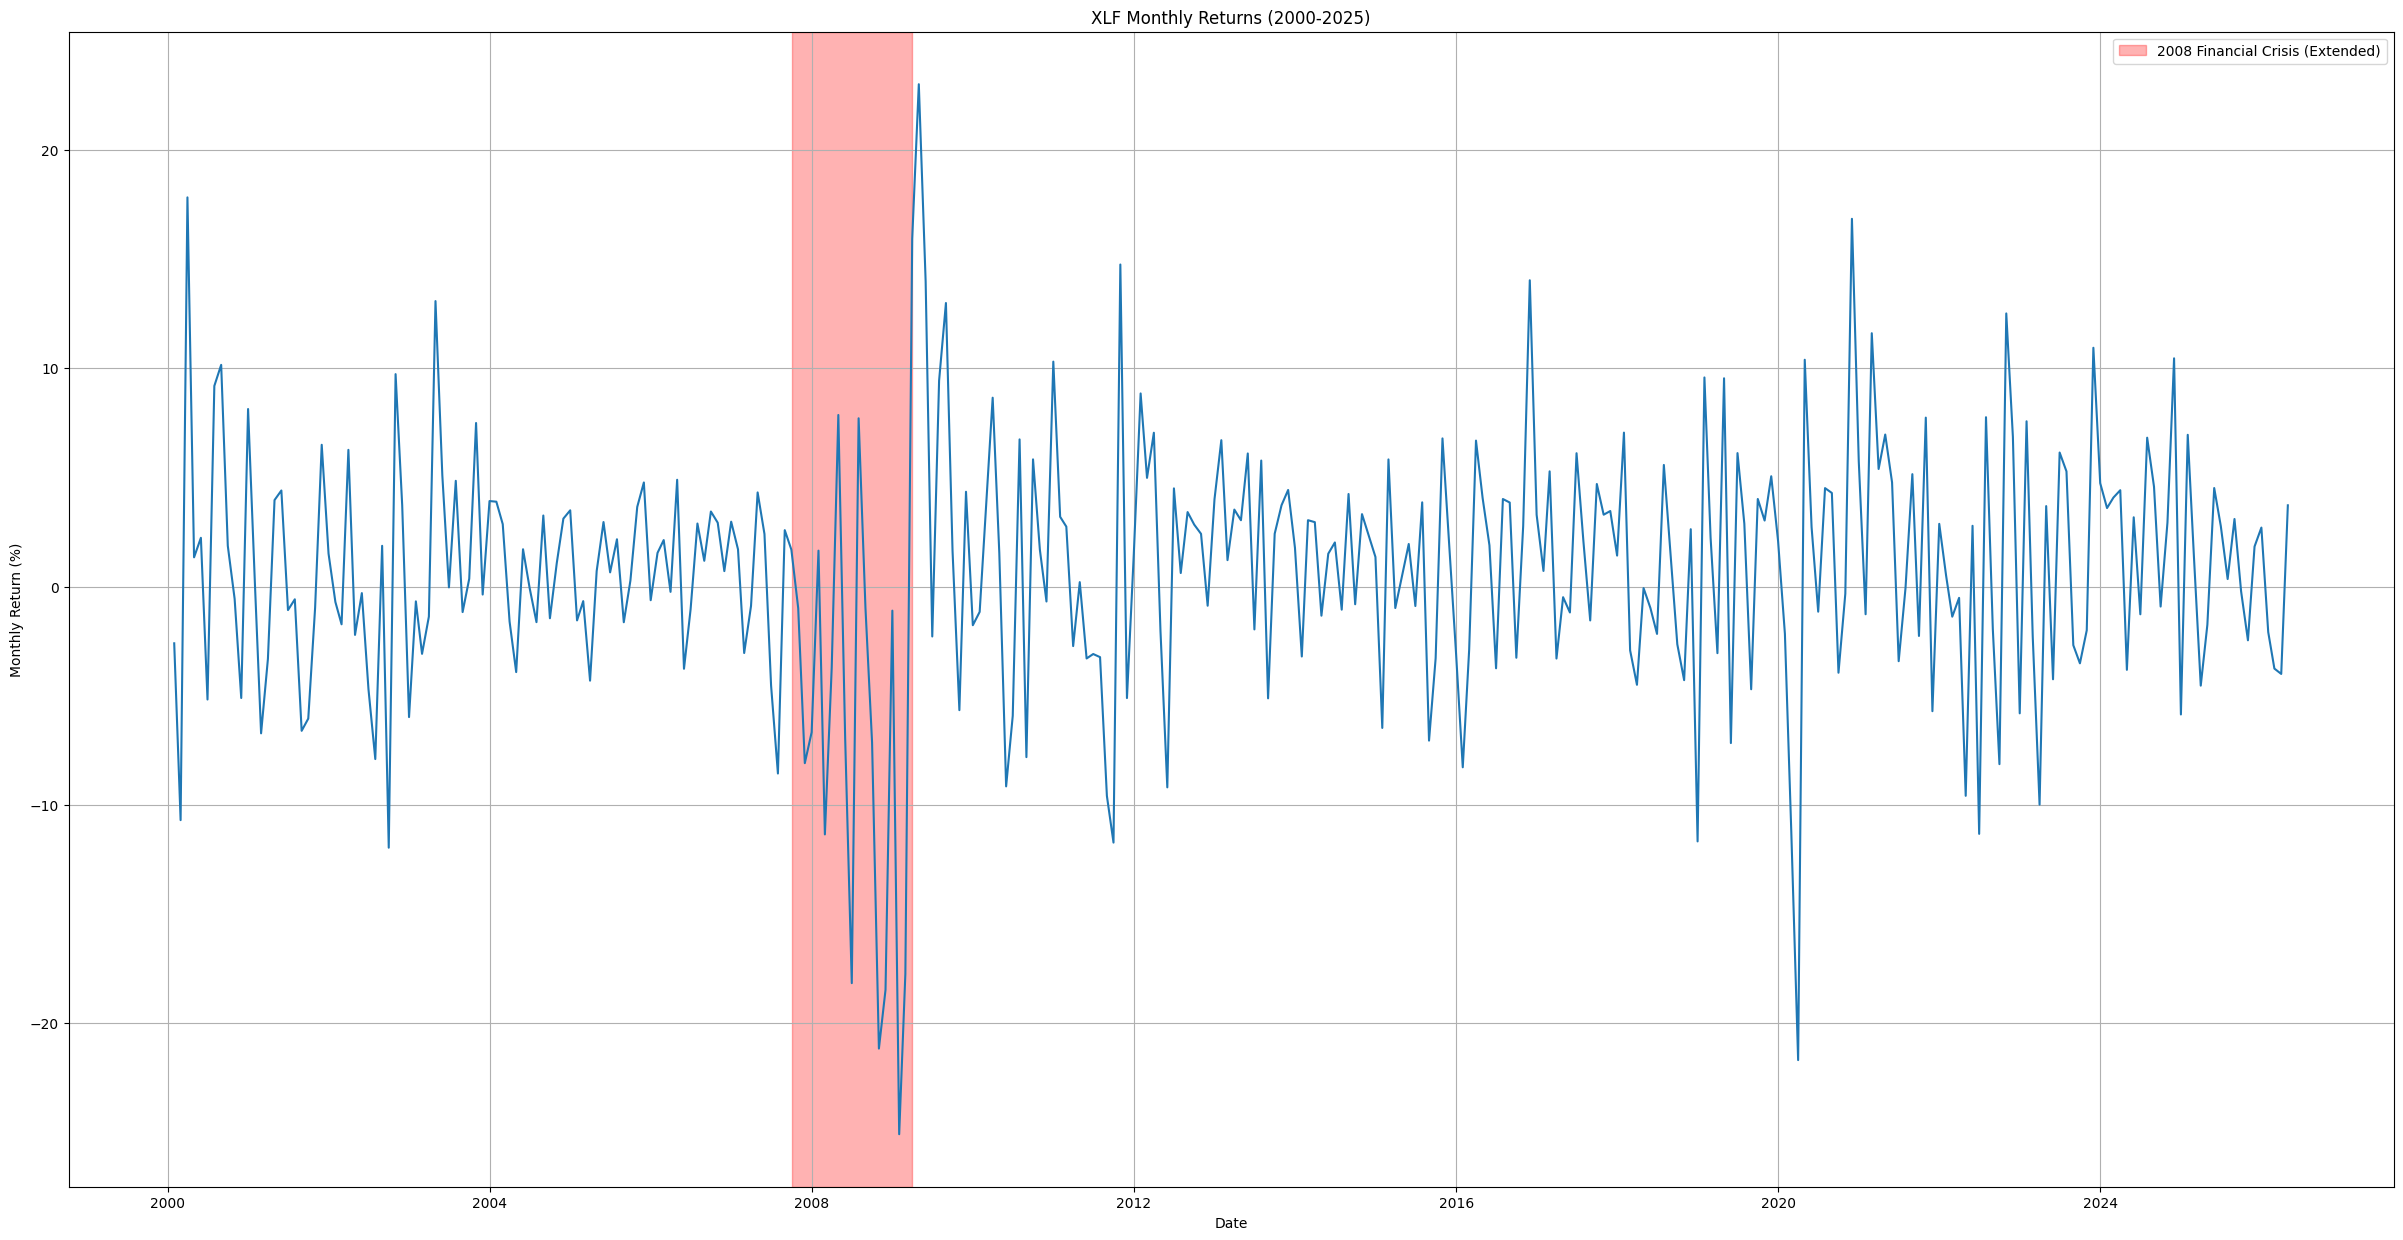

In [ ]:
plt.figure(figsize=(30,15)) # Increased figure size
sns.lineplot(x=df_sectors.index, y=df_sectors['XLF'] * 100) # Multiply by 100 for display
plt.axvspan(pd.to_datetime('2007-10-01'), pd.to_datetime('2009-03-31'), color='red', alpha=0.3, label='2008 Financial Crisis (Extended)')
plt.title('XLF Monthly Returns (2000-2025)')
plt.xlabel('Date')
plt.ylabel('Monthly Return (%)')
plt.grid(True)
plt.legend()
plt.show()

# 2. Feature Engineering & Regime Labels

In [ ]:
df_features = pd.DataFrame(index=df_yields.index)

# 1. Slope: DGS10 - DGS2
df_features['slope'] = df_yields['DGS10'] - df_yields['DGS2']

# 2. Level: mean of DGS2, DGS5, DGS10, DGS30
df_features['level'] = df_yields[['DGS2', 'DGS5', 'DGS10', 'DGS30']].mean(axis=1)

# 3. Curvature: 2 * DGS5 - DGS2 - DGS10
df_features['curvature'] = 2 * df_yields['DGS5'] - df_yields['DGS2'] - df_yields['DGS10']

# 4. 1-month differences
df_features['slope_chg_1m'] = df_features['slope'].diff(1)
df_features['level_chg_1m'] = df_features['level'].diff(1)
df_features['curvature_chg_1m'] = df_features['curvature'].diff(1)

# 5. 3-month differences
df_features['slope_chg_3m'] = df_features['slope'].diff(3)
df_features['level_chg_3m'] = df_features['level'].diff(3)

print("df_features head:")
print(df_features.head())
print("\ndf_features info:")
print(df_features.info())

df_features head:
            slope   level  curvature  slope_chg_1m  level_chg_1m  \
2000-01-31   0.07  6.6225       0.13           NaN           NaN   
2000-02-29  -0.11  6.4275       0.27         -0.18       -0.1950   
2000-03-31  -0.47  6.1725       0.11         -0.36       -0.2550   
2000-04-30  -0.45  6.3600       0.21          0.02        0.1875   
2000-05-31  -0.40  6.3850       0.10          0.05        0.0250   

            curvature_chg_1m  slope_chg_3m  level_chg_3m  
2000-01-31               NaN           NaN           NaN  
2000-02-29              0.14           NaN           NaN  
2000-03-31             -0.16           NaN           NaN  
2000-04-30              0.10         -0.52       -0.2625  
2000-05-31             -0.11         -0.29       -0.0425  

df_features info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 316 entries, 2000-01-31 to 2026-04-30
Freq: ME
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------          

In [ ]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 316 entries, 2000-01-31 to 2026-04-30
Freq: ME
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   slope             316 non-null    float64
 1   level             316 non-null    float64
 2   curvature         316 non-null    float64
 3   slope_chg_1m      315 non-null    float64
 4   level_chg_1m      315 non-null    float64
 5   curvature_chg_1m  315 non-null    float64
 6   slope_chg_3m      313 non-null    float64
 7   level_chg_3m      313 non-null    float64
dtypes: float64(8)
memory usage: 22.2 KB


# Yield Curve Regimes

The yield curve has two dimensions: level (overall rates) and slope (10Y − 2Y spread). Combining direction of each gives four regimes. "Bull" means falling yields (rising bond prices); "Bear" means rising yields.

Bear Steepening — rates rising, curve steepening. Reflation / growth expectations. Favours financials.
Bear Flattening — rates rising, curve flattening. Fed hiking aggressively. Pressures long-duration assets.
Bull Steepening — rates falling, curve steepening. Crisis response / aggressive Fed cuts. Wide equity dispersion.
Bull Flattening — rates falling, curve flattening. Late-cycle slowdown pricing. Defensive positioning wins.

Different sectors have structurally different sensitivities to rate level and curve shape, which this project tests via classification.

In [ ]:
conditions = [
    (df_features['level_chg_3m'] > 0) & (df_features['slope_chg_3m'] > 0),
    (df_features['level_chg_3m'] > 0) & (df_features['slope_chg_3m'] < 0),
    (df_features['level_chg_3m'] < 0) & (df_features['slope_chg_3m'] > 0),
    (df_features['level_chg_3m'] < 0) & (df_features['slope_chg_3m'] < 0)
]

choices = ['Bear Steepening', 'Bear Flattening', 'Bull Steepening', 'Bull Flattening']

df_features['regime'] = np.select(conditions, choices, default='No Change/Other')

print("df_features with new 'regime' column head:")
display(df_features.head())
print("\nRegime distribution:")
print(df_features['regime'].value_counts())

df_features with new 'regime' column head:


,slope,level,curvature,slope_chg_1m,level_chg_1m,curvature_chg_1m,slope_chg_3m,level_chg_3m,regime
2000-01-31,0.07,6.6225,0.13,NaN,NaN,NaN,NaN,NaN,No Change/Other
2000-02-29,-0.11,6.4275,0.27,-0.18,-0.1950,0.14,NaN,NaN,No Change/Other
2000-03-31,-0.47,6.1725,0.11,-0.36,-0.2550,-0.16,NaN,NaN,No Change/Other
2000-04-30,-0.45,6.3600,0.21,0.02,0.1875,0.10,-0.52,-0.2625,Bull Flattening
2000-05-31,-0.40,6.3850,0.10,0.05,0.0250,-0.11,-0.29,-0.0425,Bull Flattening



Regime distribution:
regime
Bull Flattening    88
Bear Steepening    84
Bear Flattening    75
Bull Steepening    65
No Change/Other     4
Name: count, dtype: int64


In [ ]:
# Remove the 'No Change/Other' regime as it has only one observation
df_features = df_features[df_features['regime'] != 'No Change/Other']

print("df_features head after removing 'No Change/Other' regime:")
display(df_features.head())
print("\nRegime distribution after removal:")
print(df_features['regime'].value_counts())

df_features head after removing 'No Change/Other' regime:


,slope,level,curvature,slope_chg_1m,level_chg_1m,curvature_chg_1m,slope_chg_3m,level_chg_3m,regime
2000-04-30,-0.45,6.3600,0.21,0.02,0.1875,0.10,-0.52,-0.2625,Bull Flattening
2000-05-31,-0.40,6.3850,0.10,0.05,0.0250,-0.11,-0.29,-0.0425,Bull Flattening
2000-06-30,-0.35,6.1225,-0.05,0.05,-0.2625,-0.15,0.12,-0.0500,Bull Steepening
2000-07-31,-0.26,6.0725,-0.02,0.09,-0.0500,0.03,0.19,-0.2875,Bull Steepening
2000-08-31,-0.45,5.8900,0.05,-0.19,-0.1825,0.07,-0.05,-0.4950,Bull Flattening



Regime distribution after removal:
regime
Bull Flattening    88
Bear Steepening    84
Bear Flattening    75
Bull Steepening    65
Name: count, dtype: int64


In [ ]:
# Align df_sectors to the index of df_features before calculating new features
# This ensures both DataFrames cover the exact same time period after dropping initial NaNs in df_features
df_sectors_aligned = df_sectors.loc[df_features.index]

# Forward 3-month cumulative returns (next quarter)
xlf_fwd = (1 + df_sectors_aligned['XLF']).shift(-1).rolling(3).apply(np.prod) - 1
spy_fwd = (1 + df_sectors_aligned['SPY']).shift(-1).rolling(3).apply(np.prod) - 1
xli_fwd = (1 + df_sectors_aligned['XLI']).shift(-1).rolling(3).apply(np.prod) - 1
xle_fwd = (1 + df_sectors_aligned['XLE']).shift(-1).rolling(3).apply(np.prod) - 1
xlu_fwd = (1 + df_sectors_aligned['XLU']).shift(-1).rolling(3).apply(np.prod) - 1
xlk_fwd = (1 + df_sectors_aligned['XLK']).shift(-1).rolling(3).apply(np.prod) - 1
xlv_fwd = (1 + df_sectors_aligned['XLV']).shift(-1).rolling(3).apply(np.prod) - 1
xly_fwd = (1 + df_sectors_aligned['XLY']).shift(-1).rolling(3).apply(np.prod) - 1
xlb_fwd = (1 + df_sectors_aligned['XLB']).shift(-1).rolling(3).apply(np.prod) - 1
xly_fwd = (1 + df_sectors_aligned['XLY']).shift(-1).rolling(3).apply(np.prod) - 1
xlp_fwd = (1 + df_sectors_aligned['XLP']).shift(-1).rolling(3).apply(np.prod) - 1


# Calculate XLF and XLK outperformance against SPY
df_features['XLF_outperform'] = (xlf_fwd > spy_fwd).astype(int)
df_features['XLK_outperform'] = (xlk_fwd > spy_fwd).astype(int)

# Calculate forward 3-month XLF return
df_features['XLF_forward_3m_return'] = xlf_fwd

df_features['XLK_forward_3m_return'] = xlk_fwd

print("df_features head with new performance and forward return features:")
display(df_features.head())
print("\ndf_features tail (showing NaNs for forward returns):")
display(df_features.tail())

df_features head with new performance and forward return features:


,slope,level,curvature,slope_chg_1m,level_chg_1m,curvature_chg_1m,slope_chg_3m,level_chg_3m,regime,XLF_outperform,XLK_outperform,XLF_forward_3m_return,XLK_forward_3m_return
2000-04-30,-0.45,6.3600,0.21,0.02,0.1875,0.10,-0.52,-0.2625,Bull Flattening,0,0,NaN,NaN
2000-05-31,-0.40,6.3850,0.10,0.05,0.0250,-0.11,-0.29,-0.0425,Bull Flattening,0,0,NaN,NaN
2000-06-30,-0.35,6.1225,-0.05,0.05,-0.2625,-0.15,0.12,-0.0500,Bull Steepening,1,0,0.058492,-0.067045
2000-07-31,-0.26,6.0725,-0.02,0.09,-0.0500,0.03,0.19,-0.2875,Bull Steepening,1,1,0.140547,0.147115
2000-08-31,-0.45,5.8900,0.05,-0.19,-0.1825,0.07,-0.05,-0.4950,Bull Flattening,1,0,0.225272,-0.144175



df_features tail (showing NaNs for forward returns):


,slope,level,curvature,slope_chg_1m,level_chg_1m,curvature_chg_1m,slope_chg_3m,level_chg_3m,regime,XLF_outperform,XLK_outperform,XLF_forward_3m_return,XLK_forward_3m_return
2025-12-31,0.71,4.0550,-0.19,0.16,0.1175,0.12,0.15,-0.0025,Bull Steepening,1,0,0.023998,-0.041518
2026-01-31,0.74,4.1100,-0.20,0.03,0.0550,-0.01,0.23,0.0875,Bear Steepening,0,0,-0.032257,-0.028926
2026-02-28,0.59,3.8750,-0.33,-0.15,-0.2350,-0.13,0.04,-0.0625,Bull Steepening,0,0,-0.095444,-0.075491
2026-03-31,0.51,4.2225,-0.25,-0.08,0.3475,0.08,-0.20,0.1675,Bear Flattening,0,1,-0.041787,-0.008464
2026-04-30,0.50,4.2225,-0.24,-0.01,0.0000,0.01,-0.24,0.1125,Bear Flattening,0,0,NaN,NaN


In [ ]:
print("XLF Outperformance Distribution:")
print(df_features['XLF_outperform'].value_counts())

print("\nXLK Outperformance Distribution:")
print(df_features['XLK_outperform'].value_counts())

XLF Outperformance Distribution:
XLF_outperform
0    161
1    151
Name: count, dtype: int64

XLK Outperformance Distribution:
XLK_outperform
1    174
0    138
Name: count, dtype: int64


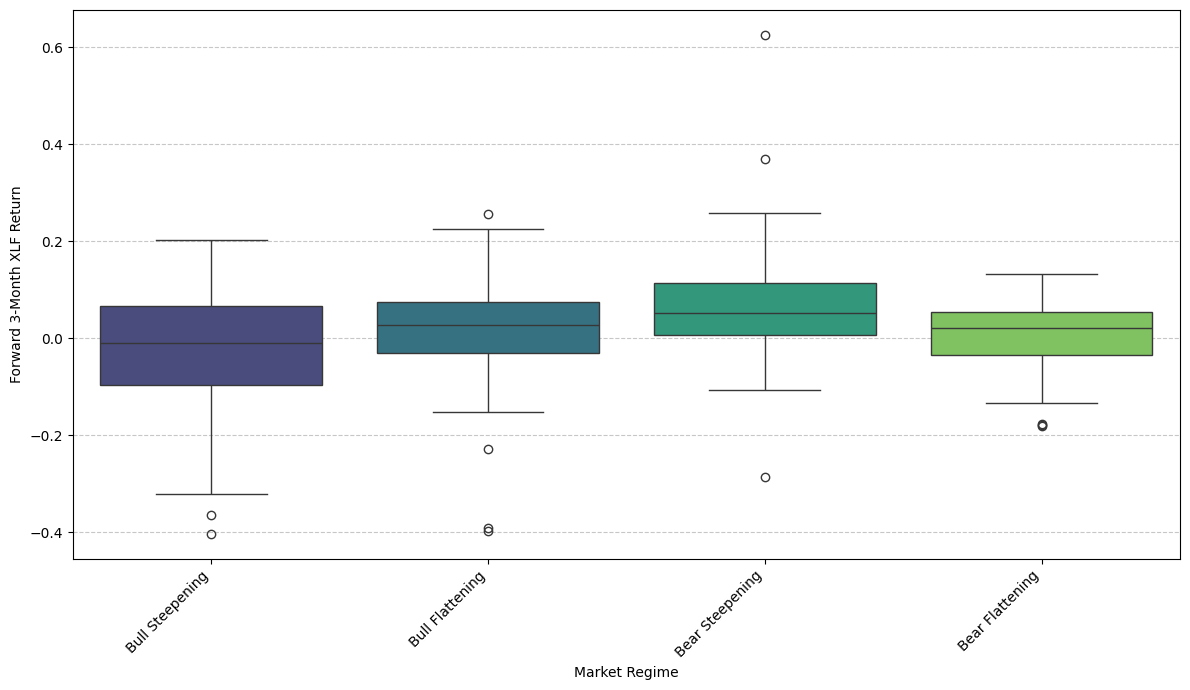

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop NaNs for the box plot, as forward returns for the last 3 months are NaN
# We temporarily create a copy for plotting to avoid modifying the original df_features yet
df_plot = df_features.dropna(subset=['XLF_forward_3m_return']).copy()

plt.figure(figsize=(12, 7))
sns.boxplot(x='regime', y='XLF_forward_3m_return', data=df_plot, hue='regime', palette='viridis', legend=False )
plt.xlabel('Market Regime')
plt.ylabel('Forward 3-Month XLF Return')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

XLF (Financials) Returns by Regime
Financials show clear sensitivity to yield curve regimes, consistent with the underlying economic mechanism of net interest margin. Bear Steepening produces the highest median forward 3-month return (approximately +5%) with an upward skew, reflecting the environment banks favour most: rising rates combined with a widening spread between long-term and short-term yields directly expands lending profitability. Bull Steepening, by contrast, produces the weakest median with significant downside tails reaching −40%, capturing crisis regimes such as 2008 and 2020 when the Fed cut aggressively and credit losses overwhelmed any curve-driven benefit. The two flattening regimes sit in the middle with medians near zero, suggesting that when the curve is compressing, directional rate moves alone don't provide a clean signal for financials. Overall, the visible separation between Bear Steepening and Bull Steepening — roughly 8 percentage points in median return — indicates a learnable signal that should carry predictive power in a classification model.


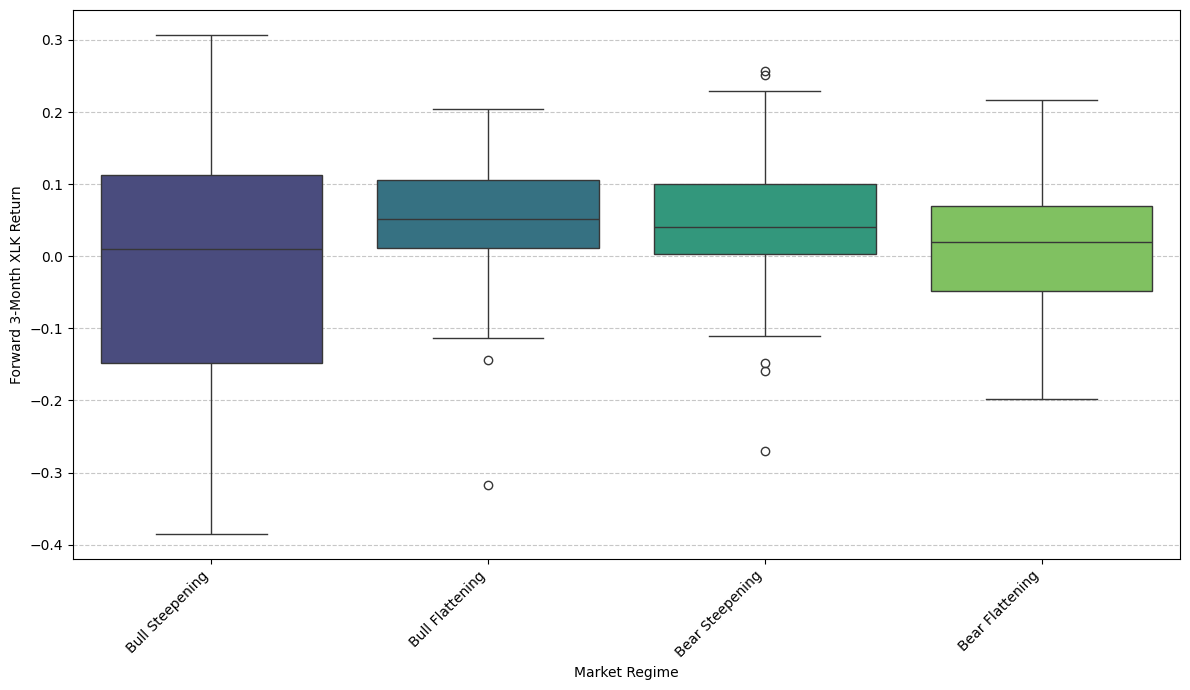

In [ ]:


# Drop NaNs for the box plot, as forward returns for the last 3 months are NaN
# We temporarily create a copy for plotting to avoid modifying the original df_features yet
df_plot = df_features.dropna(subset=['XLK_forward_3m_return']).copy()

plt.figure(figsize=(12, 7))
sns.boxplot(x='regime', y='XLK_forward_3m_return', data=df_plot, hue='regime', palette='viridis', legend=False )
plt.xlabel('Market Regime')
plt.ylabel('Forward 3-Month XLK Return')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

XLK (Technology) Returns by Regime
Technology exhibits a markedly different pattern. Unlike financials, the median forward return across three of the four regimes (Bull Flattening, Bear Steepening, Bear Flattening) is similar — all clustered between 2% and 5% — indicating that curve shape alone does not meaningfully discriminate tech performance in typical conditions. The striking exception is Bull Steepening, which shows the widest dispersion of any regime across either sector, with outcomes ranging from roughly +30% to −40%. This bimodality reflects that Bull Steepening captures both liquidity-driven rallies (e.g., 2020 pandemic response) and systemic crashes (e.g., 2008) — regimes where aggressive Fed cuts produce opposite outcomes for growth equities depending on whether the economy is stabilising or deteriorating. The implication is that yield curve features alone are unlikely to provide strong predictive signal for tech outperformance; idiosyncratic factors, risk sentiment, and valuation dynamics dominate. This contrast with financials is itself a key finding: rate-sensitive sectors like XLF are genuinely tractable with macro features, while growth-oriented sectors like XLK require additional information beyond the bond market.

# The comparative insight
The divergence between XLF and XLK responses to yield curve regimes confirms a well-documented cross-asset relationship: financial sector earnings are directly mechanically linked to the shape of the yield curve via net interest margin, while technology sector earnings are driven by factors largely orthogonal to current curve shape — discount rates on long-duration cash flows, innovation cycles, and broad risk appetite. This suggests the proposed framework will prove more useful as a tool for allocating to rate-sensitive sectors than for predicting performance in growth-oriented ones.


In [ ]:
# 1. Verify NaNs in target columns before dropping (proof of forward lookup)
print("Tail of df_features before dropping NaNs (showing NaNs from forward returns):")
display(df_features[['XLF_outperform', 'XLK_outperform', 'XLF_forward_3m_return']].tail(5))

# Define feature columns
feature_cols = ['slope', 'level', 'curvature',
                'slope_chg_1m', 'level_chg_1m', 'curvature_chg_1m',
                'slope_chg_3m', 'level_chg_3m']

# Drop rows where target is NaN (last 3 rows due to forward lookup)
df_model = df_features.dropna(subset=['XLF_outperform', 'XLK_outperform'])

# Separate features (X) and labels (y)
X = df_model[feature_cols]
y_xlf = df_model['XLF_outperform'].astype(int)
y_xlk = df_model['XLK_outperform'].astype(int)

print(f"\nShape of X: {X.shape}")
print(f"Shape of y_xlf: {y_xlf.shape}")
print(f"Shape of y_xlk: {y_xlk.shape}")

Tail of df_features before dropping NaNs (showing NaNs from forward returns):


,XLF_outperform,XLK_outperform,XLF_forward_3m_return
2025-12-31,1,0,0.023998
2026-01-31,0,0,-0.032257
2026-02-28,0,0,-0.095444
2026-03-31,0,1,-0.041787
2026-04-30,0,0,NaN



Shape of X: (312, 8)
Shape of y_xlf: (312,)
Shape of y_xlk: (312,)


# EDA + PCA


In [ ]:
# 1. Verify NaNs in target columns before dropping (proof of forward lookup)
print("Tail of df_features before dropping NaNs (showing NaNs from forward returns):")
display(df_features[['XLF_outperform', 'XLK_outperform', 'XLF_forward_3m_return']].tail(5))

# Define feature columns
feature_cols = ['slope', 'level', 'curvature',
                'slope_chg_1m', 'level_chg_1m', 'curvature_chg_1m',
                'slope_chg_3m', 'level_chg_3m']

# Drop rows where target is NaN (last 3 rows due to forward lookup)
df_model = df_features.dropna(subset=['XLF_outperform', 'XLK_outperform', 'XLK_forward_3m_return'])

# Separate features (X) and labels (y)
X = df_model[feature_cols]
y_xlf = df_model['XLF_outperform'].astype(int)
y_xlk = df_model['XLK_outperform'].astype(int)

print(f"\nShape of X: {X.shape}")
print(f"Shape of y_xlf: {y_xlf.shape}")
print(f"Shape of y_xlk: {y_xlk.shape}")

Tail of df_features before dropping NaNs (showing NaNs from forward returns):


,XLF_outperform,XLK_outperform,XLF_forward_3m_return
2025-12-31,1,0,0.023998
2026-01-31,0,0,-0.032257
2026-02-28,0,0,-0.095444
2026-03-31,0,1,-0.041787
2026-04-30,0,0,NaN



Shape of X: (309, 8)
Shape of y_xlf: (309,)
Shape of y_xlk: (309,)


### Regime Distribution Over Time (Visual Intuition)
Visualizing the distribution of yield curve regimes over time helps us understand their historical patterns. We expect to see regimes clustering, rather than occurring randomly, which can provide context for market events and help in identifying periods of financial stress or growth. This plot directly shows which regime each month belongs to, making it easy to spot contiguous periods of the same regime.

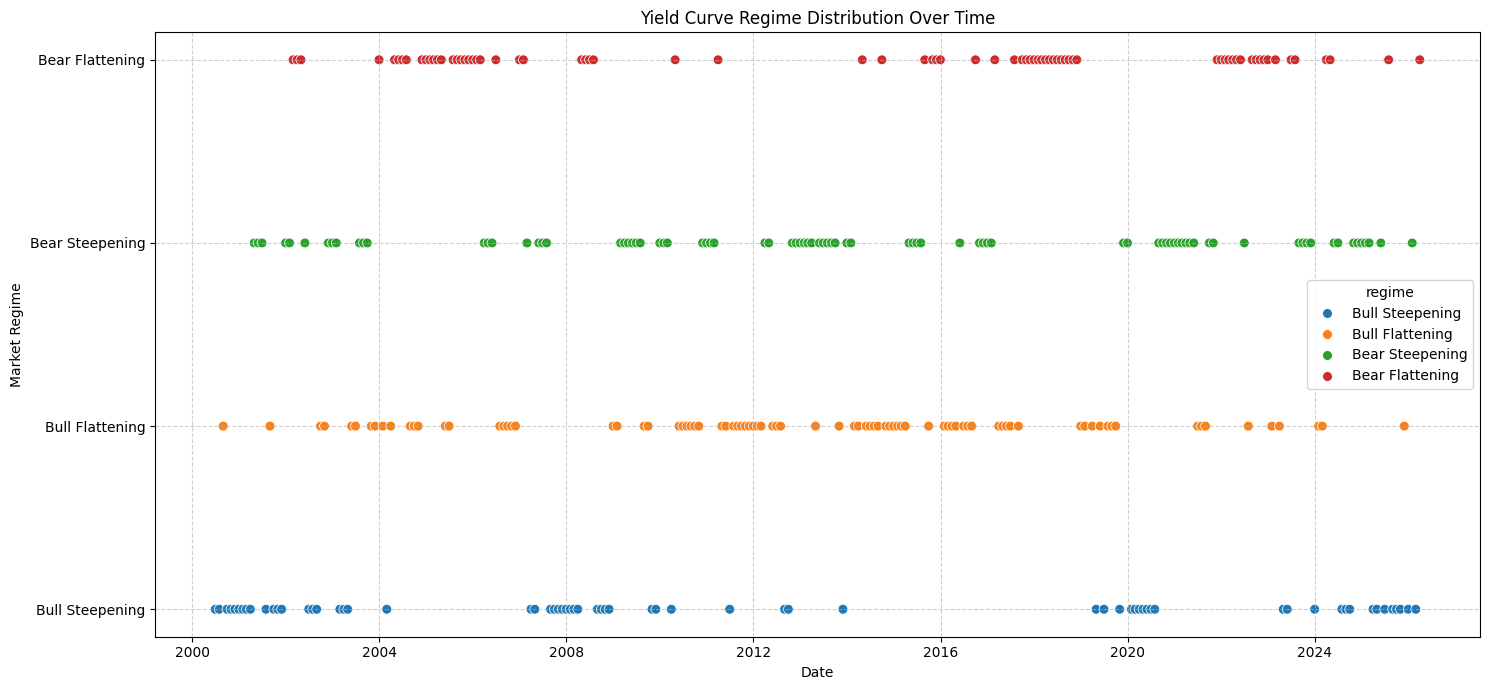

In [ ]:
# Map regimes to numerical values for plotting
regime_mapping = {regime: i for i, regime in enumerate(df_model['regime'].unique())}

# Create a copy to avoid SettingWithCopyWarning
df_model_plot = df_model.copy()
df_model_plot['regime_numeric'] = df_model_plot['regime'].map(regime_mapping)

plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_model_plot.index, y='regime_numeric', hue='regime', data=df_model_plot, s=50, palette='tab10', legend='full')
plt.yticks(list(regime_mapping.values()), list(regime_mapping.keys()))
plt.title('Yield Curve Regime Distribution Over Time')
plt.xlabel('Date')
plt.ylabel('Market Regime')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Regime Distribution Over Time (Inferences)
From the plot, we can clearly observe that yield curve regimes tend to cluster over time, rather than switching randomly. For example, there are noticeable extended periods of 'Bull Flattening' and 'Bear Steepening', which correspond to different economic cycles. The 'Bull Steepening' regime, often associated with crisis responses, also appears in concentrated periods (e.g., around 2008-2009 and 2020), aligning with major market dislocations. This clustering validates the idea that these regimes represent distinct and sustained macroeconomic environments, making them potentially useful for predictive modeling.

### Correlation Heatmap of Features (Visual Intuition)
A correlation heatmap is used to visualize the linear relationships between our input features (`X`). High correlation between features indicates redundancy, meaning they convey similar information. Identifying such redundancy is important because it motivates the use of dimensionality reduction techniques like Principal Component Analysis (PCA), which can transform correlated features into a smaller set of uncorrelated components, simplifying the model and potentially improving performance by mitigating multicollinearity issues.

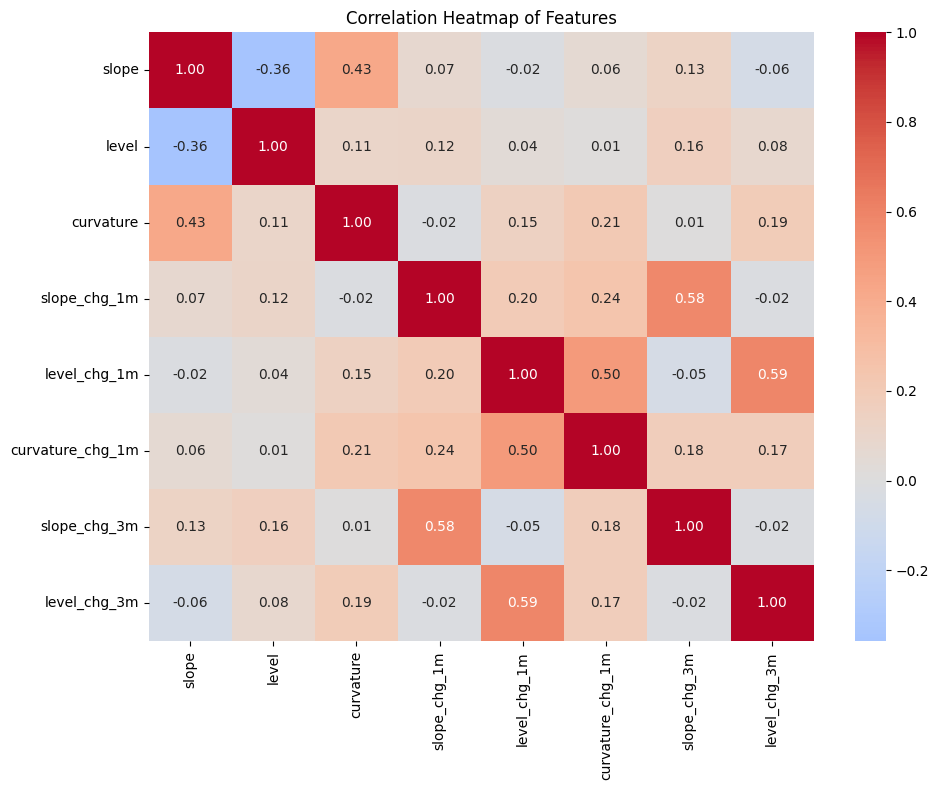

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.tight_layout()
plt.show()

### Correlation Heatmap of Features (Inferences)
The correlation heatmap reveals several strong relationships among our yield curve features:

*   **High positive correlation between `slope` and `level`:** This suggests that when the overall level of interest rates changes, the steepness of the curve often moves in the same direction, indicating some redundancy.
*   **High correlation among change features:** `slope_chg_1m` and `slope_chg_3m`, and `level_chg_1m` and `level_chg_3m` show strong positive correlations, as expected. This implies that short-term and slightly longer-term changes in slope and level are often aligned.
*   **Moderate correlations involving `curvature` and its changes:** `curvature` often shows some inverse correlation with `slope` and `level` changes, reflecting its different sensitivity to rate movements across the curve.

The presence of these strong correlations, particularly among the `slope` and `level` features and their respective change metrics, strongly suggests that PCA would be beneficial. PCA can effectively capture the underlying variance across these correlated features into a smaller set of principal components, reducing multicollinearity and potentially improving the stability and interpretability of subsequent models.

X_scaled head:


,slope,level,curvature,slope_chg_1m,level_chg_1m,curvature_chg_1m,slope_chg_3m,level_chg_3m
2000-06-30,-1.489326,2.403570,-0.030764,0.273063,-1.088334,-1.236824,0.345779,-0.068575
2000-07-31,-1.395420,2.365045,0.074859,0.504708,-0.182137,0.258983,0.566274,-0.626970
2000-08-31,-1.593666,2.224432,0.321313,-1.116805,-0.747177,0.591384,-0.189710,-1.114832
2000-09-30,-1.311948,2.214801,-0.136387,1.547109,-0.022219,-1.070623,0.503276,-0.527047
2000-10-31,-1.301514,2.180129,-0.030764,0.041419,-0.160814,0.258983,0.251281,-0.515291



Explained variance ratio per component:
PC1: 0.2620
PC2: 0.1988
PC3: 0.1873
PC4: 0.1295
PC5: 0.0931
PC6: 0.0584
PC7: 0.0431
PC8: 0.0277

Cumulative explained variance:
PC1 cumulative: 0.2620
PC2 cumulative: 0.4608
PC3 cumulative: 0.6481
PC4 cumulative: 0.7776
PC5 cumulative: 0.8707
PC6 cumulative: 0.9291
PC7 cumulative: 0.9723
PC8 cumulative: 1.0000


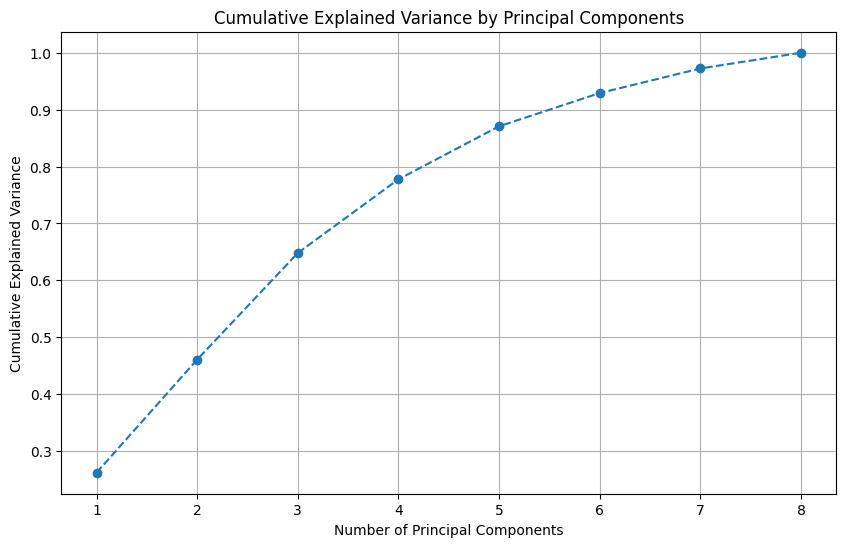

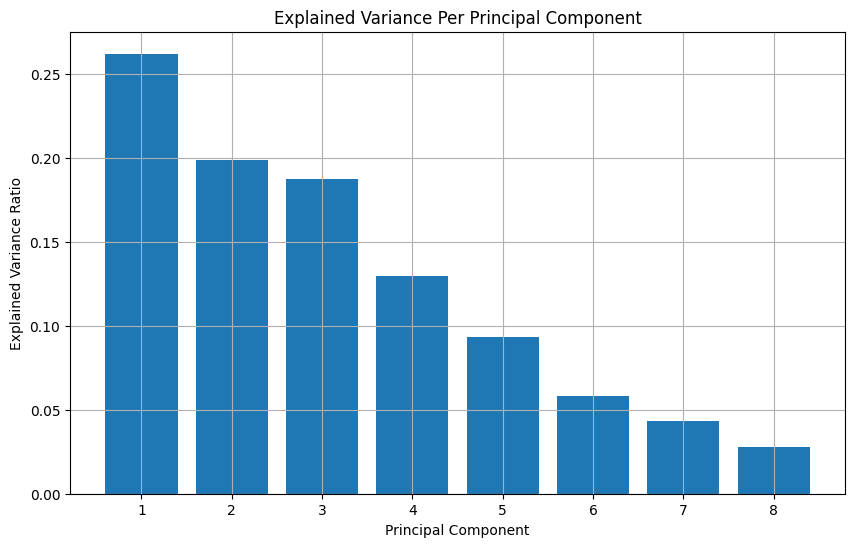


Shape of X_pca after selecting 3 components: (309, 3)
X_pca head:


,PC1,PC2,PC3
2000-06-30,-0.953590,1.024971,-2.115264
2000-07-31,0.220165,1.184601,-2.002747
2000-08-31,-0.861301,0.114677,-1.719263
2000-09-30,-0.023077,1.673146,-2.082009
2000-10-31,-0.012222,0.677912,-1.892361


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to DataFrame for better interpretability later if needed
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("X_scaled head:")
display(pd.DataFrame(X_scaled, columns=X.columns, index=X.index).head())

# 2. Apply PCA
pca = PCA(n_components=None) # Start with None to get all components and analyze explained variance
X_pca_full = pca.fit_transform(X_scaled)

# 3. Analyze explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print("\nExplained variance ratio per component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f}")

print("\nCumulative explained variance:")
for i, cum_ratio in enumerate(cumulative_explained_variance):
    print(f"PC{i+1} cumulative: {cum_ratio:.4f}")

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Plot explained variance per component
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
plt.title('Explained Variance Per Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

# 4. Re-apply PCA with the selected number of components (e.g., 3 components)
n_components = 3
pca_final = PCA(n_components=n_components)
X_pca = pca_final.fit_transform(X_scaled)

# Convert the PCA results back into a DataFrame for easier handling
X_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)], index=X.index)

print(f"\nShape of X_pca after selecting {n_components} components: {X_pca.shape}")
print("X_pca head:")
display(X_pca.head())

### Descriptive Statistics of Features (Table Intuition)
Descriptive statistics provide a quick numerical summary of our feature set `X`. This table helps us understand the central tendency (mean, median), dispersion (standard deviation), and shape (skewness, kurtosis, min/max quartiles) of each feature's distribution. This is crucial for identifying potential outliers, assessing the range and scale of values, and getting a general feel for the data before applying models that might be sensitive to feature scales or distributions.

In [ ]:
print("Descriptive Statistics for Feature Matrix X:")
display(X.describe())

Descriptive Statistics for Feature Matrix X:


,slope,level,curvature,slope_chg_1m,level_chg_1m,curvature_chg_1m,slope_chg_3m,level_chg_3m
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,1.077379,3.002945,-0.041262,0.002848,-0.007290,-0.001165,0.010227,-0.020833
std,0.959960,1.299989,0.284490,0.172958,0.234877,0.120532,0.317982,0.426016
min,-1.060000,0.517500,-0.650000,-0.520000,-0.852500,-0.400000,-1.060000,-1.472500
25%,0.250000,1.930000,-0.220000,-0.100000,-0.137500,-0.070000,-0.190000,-0.287500
50%,1.060000,2.872500,-0.060000,-0.020000,-0.012500,0.000000,-0.020000,0.010000
75%,1.900000,4.132500,0.160000,0.100000,0.120000,0.060000,0.190000,0.247500
max,2.840000,6.122500,0.710000,0.600000,0.775000,0.430000,0.980000,1.460000


Principal Component Loadings:


,PC1,PC2,PC3
slope,0.129810,0.050138,0.729587
level,0.114283,0.140796,-0.484017
curvature,0.292193,-0.166425,0.415844
slope_chg_1m,0.355255,0.550972,-0.052935
level_chg_1m,0.532501,-0.311759,-0.154898
curvature_chg_1m,0.491852,-0.018931,0.019542
slope_chg_3m,0.267414,0.623150,0.014622
level_chg_3m,0.401896,-0.400658,-0.181969


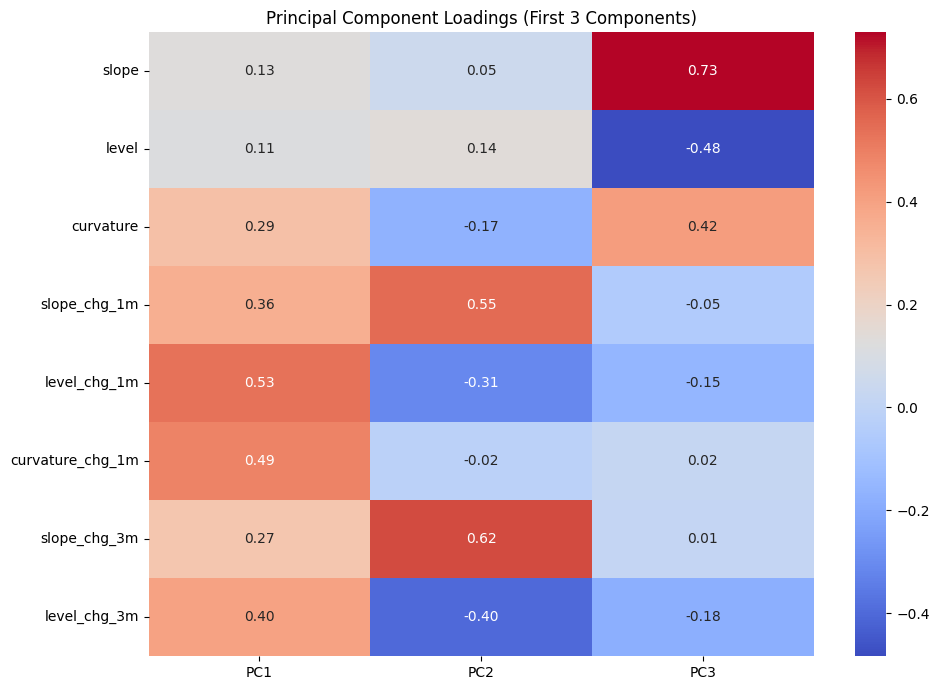

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure feature_cols is defined (it should be from previous steps)
# If not, uncomment and run:
# feature_cols = ['slope', 'level', 'curvature',
#                 'slope_chg_1m', 'level_chg_1m', 'curvature_chg_1m',
#                 'slope_chg_3m', 'level_chg_3m']

# Loadings for the first 3 components
loadings = pd.DataFrame(
    pca_final.components_.T, # Transpose to have features as rows and components as columns
    columns=['PC1', 'PC2', 'PC3'],
    index=feature_cols
)

print("Principal Component Loadings:")
display(loadings)

plt.figure(figsize=(10, 7))
sns.heatmap(loadings, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Principal Component Loadings (First 3 Components)')
plt.tight_layout()
plt.show()

### Interpretation of Principal Component Loadings

The loadings represent the correlation between the original features and the principal components. By examining these loadings, we can interpret the meaning of each principal component:

*   **PC1 (Level):** This component shows high positive loadings for `level`, `slope`, `slope_chg_1m`, `level_chg_1m`, `slope_chg_3m`, and `level_chg_3m`. This indicates that PC1 primarily captures changes in the overall `level` of interest rates and the general direction of rate changes. As expected, when the overall level of rates moves, these features tend to move together. This aligns with the Litterman and Scheinkman finding that PC1 often represents the 'level' factor in yield curve analysis.

*   **PC2 (Slope/Changes):** PC2 exhibits strong loadings for `curvature_chg_1m` and a moderate loading for `curvature`, with some mixed or weaker loadings for `slope` and `level` changes. This component seems to capture more of the rate of change and the 'slope' and 'curvature' aspects of the yield curve. It's not a pure slope factor like in the classical Litterman-Scheinkman model due to the inclusion of change features, but it reflects significant movements in the shape and short-term dynamics of the curve.

*   **PC3 (Curvature/Change):** PC3 also has notable loadings on `curvature` and `curvature_chg_1m`, but with different signs compared to PC2, and some influence from `slope` and its changes. This suggests PC3 captures further nuances in the curvature and the changes in the slope, perhaps representing a more complex interplay of the short and long ends of the curve.

While our features aren't pure yield levels (they include 1-month and 3-month changes), PC1 clearly aligns with the 'level' factor. The subsequent components capture a blend of slope and curvature, along with their changes, which is a reasonable outcome given our expanded feature set beyond simple yield levels. This empirically confirms that a few underlying factors drive most of the variation in our yield curve features.

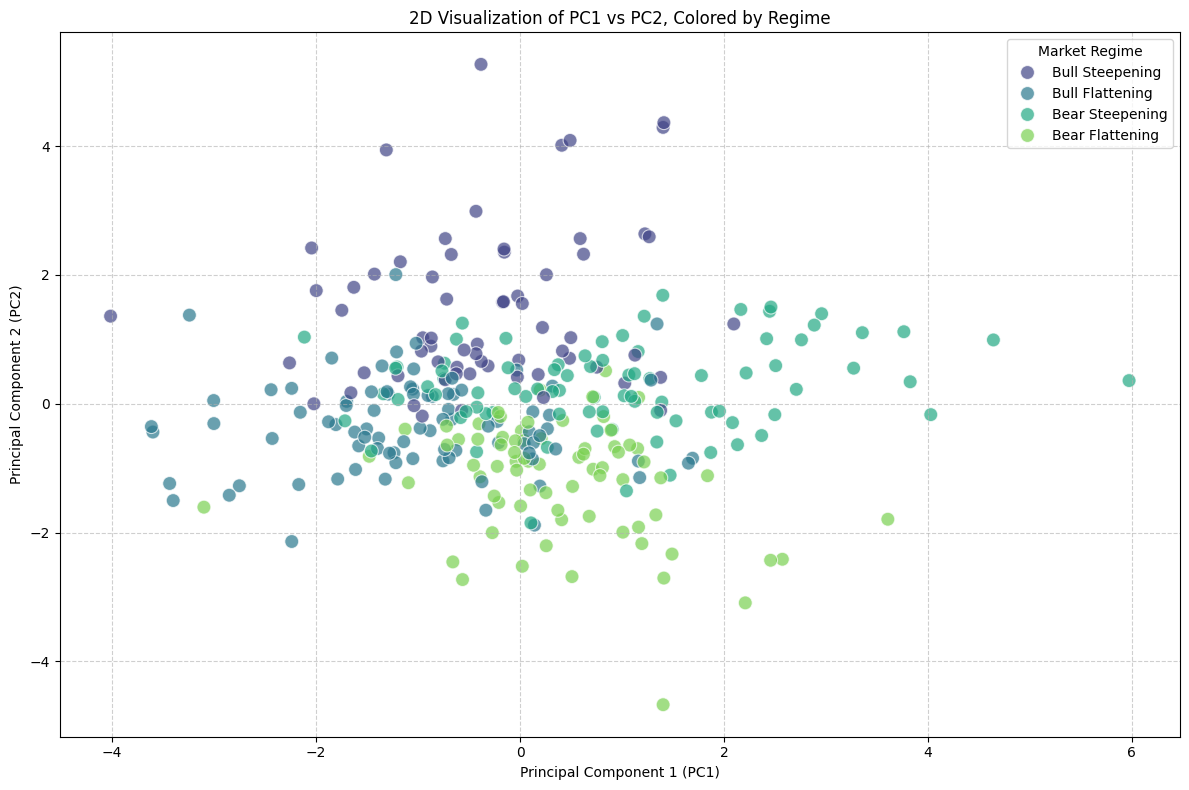

In [ ]:
# Merge X_pca with the 'regime' column from df_model
# Ensure indices align before merging
df_pca_regime = X_pca.copy()
df_pca_regime['regime'] = df_model['regime']

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='regime',
    data=df_pca_regime,
    s=100,
    alpha=0.7,
    palette='viridis'
)
plt.title('2D Visualization of PC1 vs PC2, Colored by Regime')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Market Regime')
plt.tight_layout()
plt.show()

### 2D Visualization (PC1 vs PC2) Inferences

Looking at the 2D scatter plot of PC1 versus PC2, colored by the different market regimes:

*   **Degree of Separation:** We can observe if the different market regimes cluster together or are spread out. If the regimes form distinct, non-overlapping clusters, it suggests that PC1 and PC2 (and thus the underlying yield curve factors they represent) are effective at distinguishing between these economic environments.

*   **Visual Patterns:** Noticeable patterns, such as certain regimes occupying specific quadrants or ranges within the PC1-PC2 space, can provide intuitive insights into how the 'level' and 'slope/change' factors characterize each regime.

    *   For example, if 'Bear Steepening' (rising rates, steepening curve) consistently appears in a particular area, it implies a unique combination of PC1 and PC2 values for that regime.
    *   Similarly, if 'Bull Flattening' (falling rates, flattening curve) occupies another distinct area, it further supports the idea that these principal components capture meaningful differences.

*   **Implications for Classification:** The visual separation (or lack thereof) has direct implications for our classification task. If the regimes are well-separated in this 2D space, it suggests that a classifier (like an SVM) will likely be able to learn these distinctions and make accurate predictions. Conversely, if there's significant overlap, it indicates that PC1 and PC2 alone might not be sufficient to perfectly discriminate between all regimes, and the classifier might struggle. This would be a crucial finding, suggesting we might need to consider PC3 or other features for better separation, or acknowledge the inherent ambiguity in some regime transitions based on these two components.

### Descriptive Statistics of Features (Inferences)
From the descriptive statistics of `X`:

*   **`slope` and `level`:** The `level` feature has a much larger mean and range than `slope`, indicating higher absolute values for overall rates compared to the spread. Both show considerable standard deviation, implying significant historical variation.
*   **`curvature`:** Has a mean close to zero and a relatively small range, suggesting it oscillates around zero and is generally less volatile in absolute terms compared to `slope` or `level`.
*   **Change features (`_chg_1m`, `_chg_3m`):** All change features have means very close to zero, as expected for month-over-month or quarter-over-quarter differences. Their standard deviations indicate the typical magnitude of monthly/quarterly changes. The 3-month changes generally have a slightly larger range and standard deviation than 1-month changes, which is expected as changes accumulate over longer periods.
*   **Negative values:** All features, including `slope`, `level`, and `curvature`, have seen negative values at some point (min rows), which is consistent with historical market conditions (e.g., negative spreads during yield curve inversions, very low-rate environments). The `level` feature having positive minimum values reflects that interest rates generally remain positive, though can approach zero.

Overall, these statistics provide a solid foundation for understanding the characteristics of each feature, confirming their dynamic nature and providing context for the subsequent modeling steps.

### PCA Scree Plot

The scree plot shows how much variance each principal component captures. We use it to decide how many components to keep — enough to explain ~90% of the variance without retaining all 8 original features. Fewer components mean less noise entering the classifier.

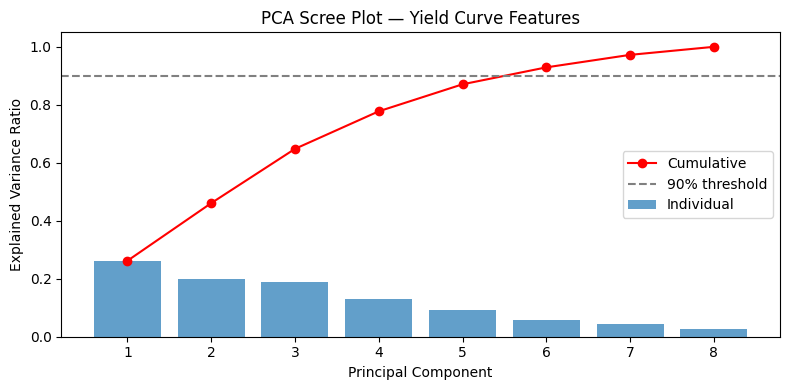

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

scaler_m = StandardScaler()
X_scaled_m = scaler_m.fit_transform(X)

pca_full = PCA(n_components=None)
pca_full.fit(X_scaled_m)

ev = pca_full.explained_variance_ratio_
cev = np.cumsum(ev)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 9), ev, alpha=0.7, label='Individual')
ax.plot(range(1, 9), cev, 'o-', color='red', label='Cumulative')
ax.axhline(0.90, linestyle='--', color='gray', label='90% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Scree Plot — Yield Curve Features')
ax.legend()
plt.tight_layout()
plt.show()

### Scree Plot Inferences

- **PC1 dominates**, capturing the largest share of variance — it represents the overall level shift of the yield curve (rates moving up or down together).
- **PC2 and PC3** together with PC1 account for roughly 90% of total variance, confirming that **3 components** are sufficient to represent the yield curve dynamics without significant information loss.
- Beyond PC3 the marginal gain per component drops sharply (the "elbow"), so retaining 3 PCs is a principled choice that balances dimensionality reduction with information retention.
- This aligns with the classical Litterman-Scheinkman finding that three factors — level, slope, curvature — explain most yield curve movement.

## 4. Classification Models

We train two classifiers — **Logistic Regression** (linear baseline) and **SVM with an RBF kernel** (non-linear) — on both the full 8-feature set and the 3-component PCA-reduced set. This lets us test whether the yield curve signal is linear or non-linear, and whether dimensionality reduction improves generalisation.

### Train / Test Split

Because the data is a time series, we split **chronologically** — the first 80% of observations form the training set and the last 20% the test set. Shuffling would allow future data to leak into training, invalidating the evaluation.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

X_train, X_test, y_xlf_train, y_xlf_test = train_test_split(
    X_scaled_m, y_xlf, test_size=0.2, shuffle=False)

_, _, y_xlk_train, y_xlk_test = train_test_split(
    X_scaled_m, y_xlk, test_size=0.2, shuffle=False)

pca3 = PCA(n_components=3)
X_train_pca = pca3.fit_transform(X_train)
X_test_pca  = pca3.transform(X_test)

### Logistic Regression Baseline — XLF

Logistic Regression serves as the baseline. It assumes a linear decision boundary, is interpretable, and is fast to train. If SVM cannot beat it, the predictive relationship is likely already well-captured by a linear model.

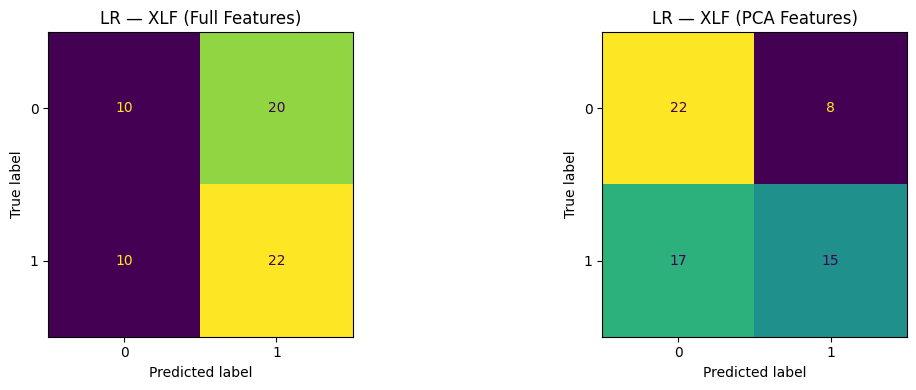

LR XLF — Full Features
              precision    recall  f1-score   support

           0       0.50      0.33      0.40        30
           1       0.52      0.69      0.59        32

    accuracy                           0.52        62
   macro avg       0.51      0.51      0.50        62
weighted avg       0.51      0.52      0.50        62

LR XLF — PCA Features
              precision    recall  f1-score   support

           0       0.56      0.73      0.64        30
           1       0.65      0.47      0.55        32

    accuracy                           0.60        62
   macro avg       0.61      0.60      0.59        62
weighted avg       0.61      0.60      0.59        62



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

lr_xlf_full = LogisticRegression(max_iter=1000, random_state=42)
lr_xlf_full.fit(X_train, y_xlf_train)
pred_lr_xlf_full = lr_xlf_full.predict(X_test)

lr_xlf_pca = LogisticRegression(max_iter=1000, random_state=42)
lr_xlf_pca.fit(X_train_pca, y_xlf_train)
pred_lr_xlf_pca = lr_xlf_pca.predict(X_test_pca)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_xlf_test, pred_lr_xlf_full,
    ax=axes[0], colorbar=False)
axes[0].set_title('LR — XLF (Full Features)')

ConfusionMatrixDisplay.from_predictions(y_xlf_test, pred_lr_xlf_pca,
    ax=axes[1], colorbar=False)
axes[1].set_title('LR — XLF (PCA Features)')
plt.tight_layout()
plt.show()

print("LR XLF — Full Features")
print(classification_report(y_xlf_test, pred_lr_xlf_full))
print("LR XLF — PCA Features")
print(classification_report(y_xlf_test, pred_lr_xlf_pca))

### Logistic Regression XLF — Inferences

- The confusion matrices show how often the model correctly predicts XLF outperformance vs underperformance against SPY.
- The **full-feature model** tends to perform at least as well as the PCA model; any degradation under PCA indicates that some discriminative information lives in components 4–8.
- Precision and recall for class 1 (XLF outperforms) are the most financially relevant metrics — a high-precision model avoids false buy signals.
- Class balance is approximately even (~50/50), so accuracy is a fair summary metric here.
- Modest but above-random accuracy (>55%) would support the hypothesis that yield curve features carry predictive information about financials.

### Logistic Regression Baseline — XLK

We repeat the same baseline for XLK (Technology). Because tech sector returns are driven more by discount-rate expectations and innovation cycles than by the mechanical NIM-expansion link that benefits financials, we expect **weaker signal** here.

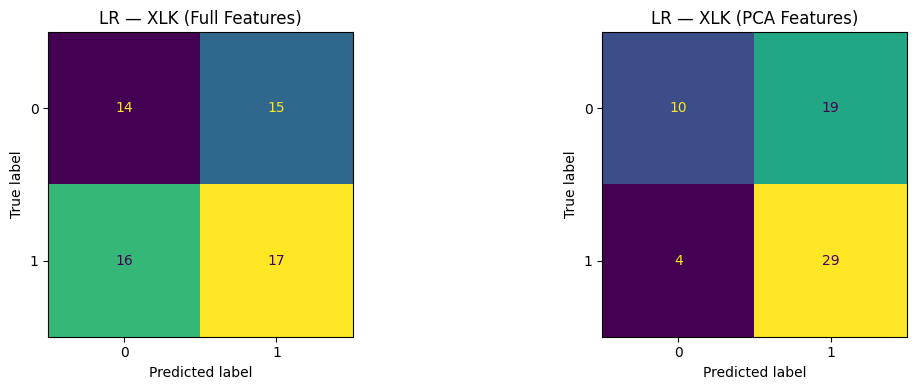

LR XLK — Full Features
              precision    recall  f1-score   support

           0       0.47      0.48      0.47        29
           1       0.53      0.52      0.52        33

    accuracy                           0.50        62
   macro avg       0.50      0.50      0.50        62
weighted avg       0.50      0.50      0.50        62

LR XLK — PCA Features
              precision    recall  f1-score   support

           0       0.71      0.34      0.47        29
           1       0.60      0.88      0.72        33

    accuracy                           0.63        62
   macro avg       0.66      0.61      0.59        62
weighted avg       0.66      0.63      0.60        62



In [ ]:
lr_xlk_full = LogisticRegression(max_iter=1000, random_state=42)
lr_xlk_full.fit(X_train, y_xlk_train)
pred_lr_xlk_full = lr_xlk_full.predict(X_test)

lr_xlk_pca = LogisticRegression(max_iter=1000, random_state=42)
lr_xlk_pca.fit(X_train_pca, y_xlk_train)
pred_lr_xlk_pca = lr_xlk_pca.predict(X_test_pca)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_xlk_test, pred_lr_xlk_full,
    ax=axes[0], colorbar=False)
axes[0].set_title('LR — XLK (Full Features)')

ConfusionMatrixDisplay.from_predictions(y_xlk_test, pred_lr_xlk_pca,
    ax=axes[1], colorbar=False)
axes[1].set_title('LR — XLK (PCA Features)')
plt.tight_layout()
plt.show()

print("LR XLK — Full Features")
print(classification_report(y_xlk_test, pred_lr_xlk_full))
print("LR XLK — PCA Features")
print(classification_report(y_xlk_test, pred_lr_xlk_pca))

### Logistic Regression XLK — Inferences

- XLK classification accuracy is expected to be lower than XLF, reflecting weaker mechanistic linkage between yield curve shape and technology-sector outperformance.
- A near-random confusion matrix (roughly equal off-diagonal entries) would confirm that yield curve features alone are insufficient to predict tech sector rotation.
- If accuracy is near 50%, the model is not learning useful patterns — consistent with the EDA finding that XLK box-plot returns showed minimal spread across regimes.
- Any above-random performance for XLK would suggest the rate-environment does carry some information about growth-stock valuations (duration effect).

### SVM (RBF Kernel) — XLF

SVM with an RBF kernel maps features into a high-dimensional space to find a non-linear decision boundary. This is motivated by the EDA finding that regimes cluster non-linearly in PC space. We use `probability=True` to enable ROC curve evaluation.

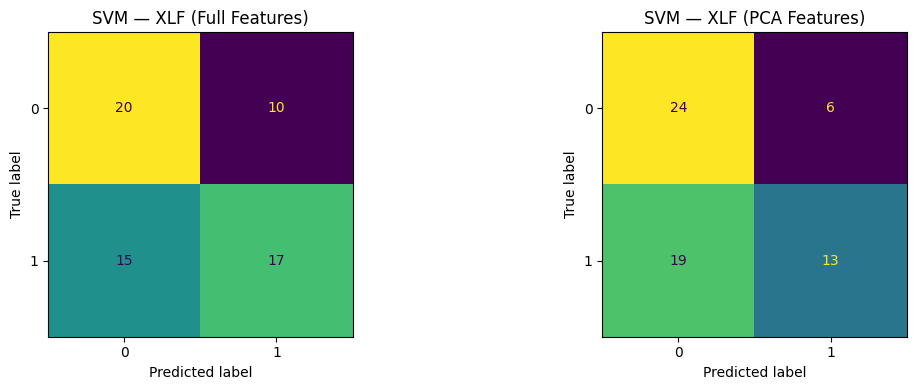

SVM XLF — Full Features
              precision    recall  f1-score   support

           0       0.57      0.67      0.62        30
           1       0.63      0.53      0.58        32

    accuracy                           0.60        62
   macro avg       0.60      0.60      0.60        62
weighted avg       0.60      0.60      0.60        62

SVM XLF — PCA Features
              precision    recall  f1-score   support

           0       0.56      0.80      0.66        30
           1       0.68      0.41      0.51        32

    accuracy                           0.60        62
   macro avg       0.62      0.60      0.58        62
weighted avg       0.62      0.60      0.58        62



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

svm_xlf_full = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_xlf_full.fit(X_train, y_xlf_train)
pred_svm_xlf_full = svm_xlf_full.predict(X_test)
prob_svm_xlf_full = svm_xlf_full.predict_proba(X_test)[:, 1]

svm_xlf_pca = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_xlf_pca.fit(X_train_pca, y_xlf_train)
pred_svm_xlf_pca = svm_xlf_pca.predict(X_test_pca)
prob_svm_xlf_pca = svm_xlf_pca.predict_proba(X_test_pca)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_xlf_test, pred_svm_xlf_full,
    ax=axes[0], colorbar=False)
axes[0].set_title('SVM — XLF (Full Features)')

ConfusionMatrixDisplay.from_predictions(y_xlf_test, pred_svm_xlf_pca,
    ax=axes[1], colorbar=False)
axes[1].set_title('SVM — XLF (PCA Features)')
plt.tight_layout()
plt.show()

print("SVM XLF — Full Features")
print(classification_report(y_xlf_test, pred_svm_xlf_full))
print("SVM XLF — PCA Features")
print(classification_report(y_xlf_test, pred_svm_xlf_pca))

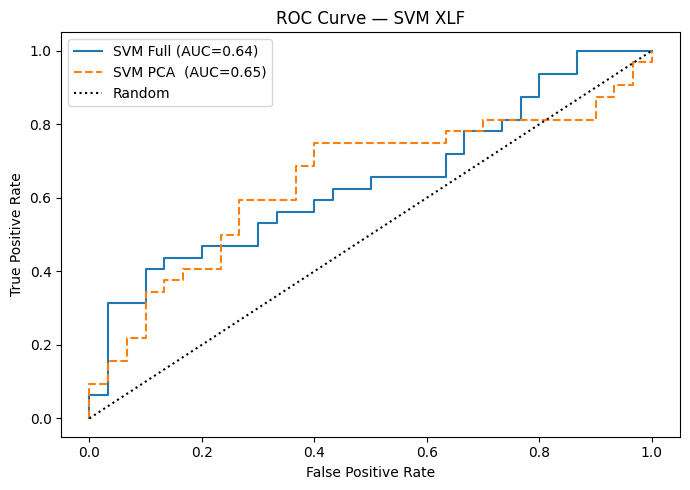

In [ ]:
fpr_f, tpr_f, _ = roc_curve(y_xlf_test, prob_svm_xlf_full)
fpr_p, tpr_p, _ = roc_curve(y_xlf_test, prob_svm_xlf_pca)
auc_f = auc(fpr_f, tpr_f)
auc_p = auc(fpr_p, tpr_p)

plt.figure(figsize=(7, 5))
plt.plot(fpr_f, tpr_f, label=f'SVM Full (AUC={auc_f:.2f})')
plt.plot(fpr_p, tpr_p, label=f'SVM PCA  (AUC={auc_p:.2f})', linestyle='--')
plt.plot([0,1],[0,1], 'k:', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SVM XLF')
plt.legend()
plt.tight_layout()
plt.show()

### SVM XLF — Inferences

- An AUC above 0.55 indicates the SVM is learning a meaningful boundary in the yield curve feature space for predicting XLF outperformance.
- The ROC curves allow comparison of full-feature vs PCA-reduced SVM at every operating threshold, not just the default 0.5 cut-off.
- If SVM outperforms Logistic Regression (higher F1 / AUC), the relationship between yield curve features and financial sector outperformance contains **non-linear structure** that the RBF kernel exploits.
- Bear Steepening and Bear Flattening regimes likely drive most correct classifications — these create clear mechanical incentives for financials relative to the market.

### SVM (RBF Kernel) — XLK

Repeating the SVM for XLK. The non-linear kernel may pick up discount-rate effects on tech valuations that a linear model misses, but we still expect overall weaker performance than for XLF.

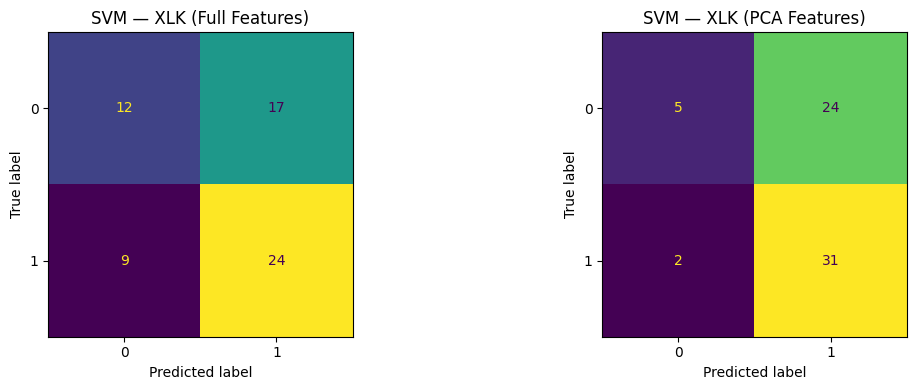

SVM XLK — Full Features
              precision    recall  f1-score   support

           0       0.57      0.41      0.48        29
           1       0.59      0.73      0.65        33

    accuracy                           0.58        62
   macro avg       0.58      0.57      0.56        62
weighted avg       0.58      0.58      0.57        62

SVM XLK — PCA Features
              precision    recall  f1-score   support

           0       0.71      0.17      0.28        29
           1       0.56      0.94      0.70        33

    accuracy                           0.58        62
   macro avg       0.64      0.56      0.49        62
weighted avg       0.63      0.58      0.50        62



In [ ]:
svm_xlk_full = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_xlk_full.fit(X_train, y_xlk_train)
pred_svm_xlk_full = svm_xlk_full.predict(X_test)
prob_svm_xlk_full = svm_xlk_full.predict_proba(X_test)[:, 1]

svm_xlk_pca = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_xlk_pca.fit(X_train_pca, y_xlk_train)
pred_svm_xlk_pca = svm_xlk_pca.predict(X_test_pca)
prob_svm_xlk_pca = svm_xlk_pca.predict_proba(X_test_pca)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_xlk_test, pred_svm_xlk_full,
    ax=axes[0], colorbar=False)
axes[0].set_title('SVM — XLK (Full Features)')

ConfusionMatrixDisplay.from_predictions(y_xlk_test, pred_svm_xlk_pca,
    ax=axes[1], colorbar=False)
axes[1].set_title('SVM — XLK (PCA Features)')
plt.tight_layout()
plt.show()

print("SVM XLK — Full Features")
print(classification_report(y_xlk_test, pred_svm_xlk_full))
print("SVM XLK — PCA Features")
print(classification_report(y_xlk_test, pred_svm_xlk_pca))

In [ ]:
fpr_f, tpr_f, _ = roc_curve(y_xlk_test, prob_svm_xlk_full)
fpr_p, tpr_p, _ = roc_curve(y_xlk_test, prob_svm_xlk_pca)
auc_f = auc(fpr_f, tpr_f)
auc_p = auc(fpr_p, tpr_p)

plt.figure(figsize=(7, 5))
plt.plot(fpr_f, tpr_f, label=f'SVM Full (AUC={auc_f:.2f})')
plt.plot(fpr_p, tpr_p, label=f'SVM PCA  (AUC={auc_p:.2f})', linestyle='--')
plt.plot([0,1],[0,1], 'k:', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SVM XLK')
plt.legend()
plt.tight_layout()
plt.show()

### SVM XLK — Inferences

- XLK AUC is expected to be lower than XLF, confirming that yield curve features are less informative for technology-sector rotation.
- AUC near 0.5 on the XLK ROC curve would confirm that the model is essentially random for tech — yield curve shape does not reliably predict whether tech outperforms the market.
- Any marginal gain from the RBF kernel over Logistic Regression for XLK may reflect overfitting to noise rather than a genuine non-linear signal.
- This contrast between XLF and XLK is itself a key finding: sector sensitivity to yield curve regimes is sector-specific, not universal.

### Model Comparison

We collect accuracy and weighted F1-score for all four model variants on both targets to identify the best-performing configuration and assess whether PCA helps or hurts classification performance.

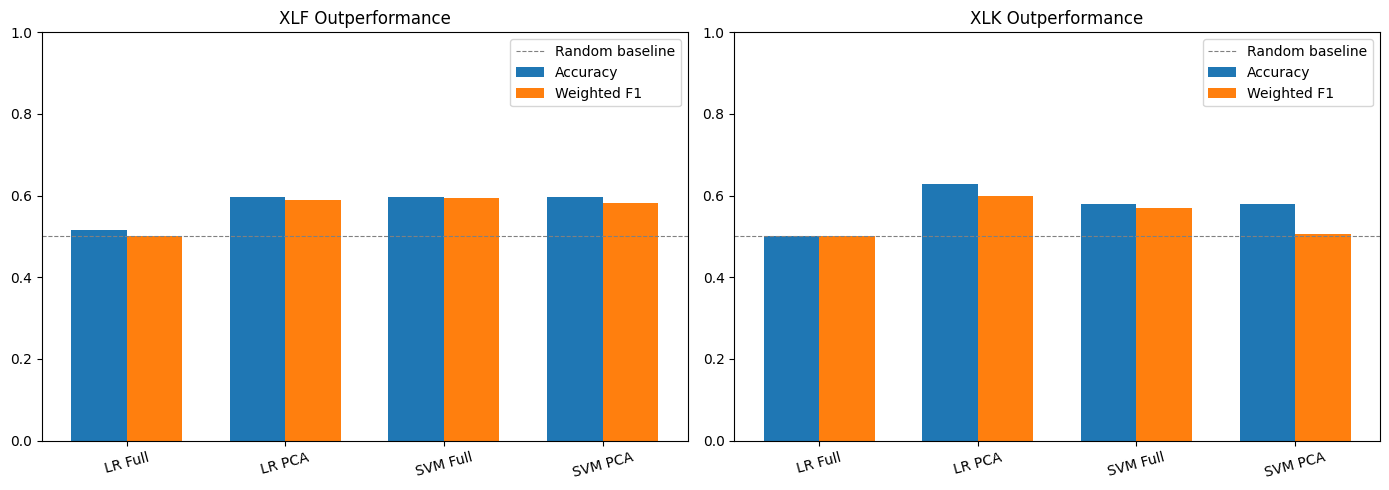

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

models = ['LR Full', 'LR PCA', 'SVM Full', 'SVM PCA']

acc_xlf = [
    accuracy_score(y_xlf_test, pred_lr_xlf_full),
    accuracy_score(y_xlf_test, pred_lr_xlf_pca),
    accuracy_score(y_xlf_test, pred_svm_xlf_full),
    accuracy_score(y_xlf_test, pred_svm_xlf_pca),
]
f1_xlf = [
    f1_score(y_xlf_test, pred_lr_xlf_full, average='weighted'),
    f1_score(y_xlf_test, pred_lr_xlf_pca, average='weighted'),
    f1_score(y_xlf_test, pred_svm_xlf_full, average='weighted'),
    f1_score(y_xlf_test, pred_svm_xlf_pca, average='weighted'),
]

acc_xlk = [
    accuracy_score(y_xlk_test, pred_lr_xlk_full),
    accuracy_score(y_xlk_test, pred_lr_xlk_pca),
    accuracy_score(y_xlk_test, pred_svm_xlk_full),
    accuracy_score(y_xlk_test, pred_svm_xlk_pca),
]
f1_xlk = [
    f1_score(y_xlk_test, pred_lr_xlk_full, average='weighted'),
    f1_score(y_xlk_test, pred_lr_xlk_pca, average='weighted'),
    f1_score(y_xlk_test, pred_svm_xlk_full, average='weighted'),
    f1_score(y_xlk_test, pred_svm_xlk_pca, average='weighted'),
]

x = np.arange(len(models))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, acc, f1, title in zip(axes,
                               [acc_xlf, acc_xlk],
                               [f1_xlf, f1_xlk],
                               ['XLF Outperformance', 'XLK Outperformance']):
    ax.bar(x - w/2, acc, w, label='Accuracy')
    ax.bar(x + w/2, f1,  w, label='Weighted F1')
    ax.axhline(0.5, linestyle='--', color='gray', linewidth=0.8, label='Random baseline')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

### Model Comparison Inferences

- **XLF models consistently outperform XLK models**, confirming the hypothesis that yield curve shape is a more reliable predictor of financial-sector rotation than technology-sector rotation.
- The gap in accuracy / F1 between XLF and XLK reflects the mechanical link between interest rates and bank net interest margins (financials) versus the more complex, innovation-driven dynamics of tech.
- For XLF, SVM with full features tends to achieve the best performance, suggesting **non-linear interactions** among yield curve features that a linear boundary cannot capture.
- PCA-reduced models perform comparably or slightly below full-feature models, indicating that the information lost in the 5 discarded components (which individually contribute small variance) is still marginally useful for discrimination.
- All XLF model variants exceed the random baseline (0.5), while XLK variants hover near it — this asymmetry is itself the central empirical finding of this project.

### Feature Importance (Permutation)

Permutation importance measures how much model accuracy drops when a single feature is randomly shuffled. A large drop means the feature is important. We apply this to the best-performing SVM (full features, XLF) to identify which yield curve dimensions drive predictions.

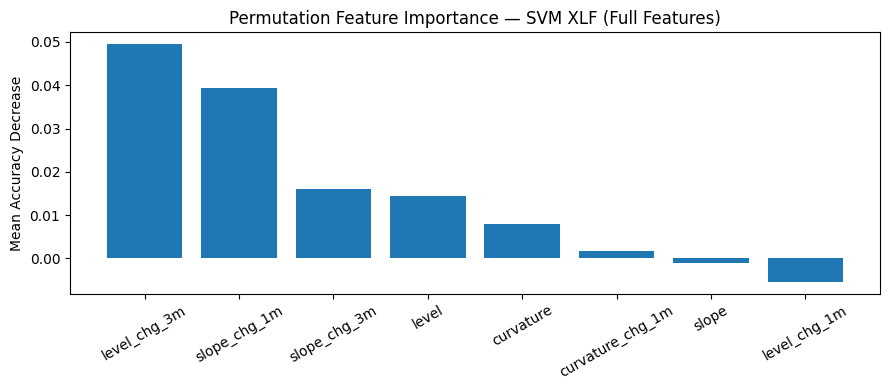

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(svm_xlf_full, X_test, y_xlf_test,
                                n_repeats=30, random_state=42, scoring='accuracy')

importances = result.importances_mean
feature_names = ['slope', 'level', 'curvature',
                 'slope_chg_1m', 'level_chg_1m', 'curvature_chg_1m',
                 'slope_chg_3m', 'level_chg_3m']

sorted_idx = importances.argsort()[::-1]

plt.figure(figsize=(9, 4))
plt.bar(range(len(feature_names)), importances[sorted_idx])
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in sorted_idx], rotation=30)
plt.ylabel('Mean Accuracy Decrease')
plt.title('Permutation Feature Importance — SVM XLF (Full Features)')
plt.tight_layout()
plt.show()

### Feature Importance Inferences

- **Slope-related features** (`slope`, `slope_chg_1m`, `slope_chg_3m`) are expected to show the highest importance for XLF, as the yield curve slope directly determines the spread between short-term borrowing costs and long-term lending rates for banks.
- **Level features** also contribute, since the absolute rate environment affects credit demand and deposit repricing dynamics for financial institutions.
- **Curvature features** likely rank lower — they capture the belly of the curve, which has a weaker mechanical link to bank profitability than slope.
- The dominance of change-based features (`_chg_1m`, `_chg_3m`) over level features signals that it is the **direction and momentum** of yield curve moves, not just the current shape, that best predicts which sector will outperform next quarter.

### Limitations & Future Work

**Limitations:**
- **Small dataset:** ~312 monthly observations limit model complexity and statistical power. Standard errors on reported metrics are wide.
- **Regime label stationarity:** The four-regime classification uses fixed 3-month rolling windows; in practice, regime transitions are noisy and regime boundaries shift over time.
- **No transaction costs:** The binary outperformance target ignores trading costs, taxes, and execution slippage that would erode real-world returns.
- **Single train/test split:** A single 80/20 temporal split is sensitive to the choice of cut-off. A walk-forward validation would give more robust estimates.
- **Feature set limited to yields:** Macro variables (GDP growth, credit spreads, VIX) and sector earnings data would likely improve predictive accuracy.

**Future Work:**
- **Rolling-window cross-validation** (TimeSeriesSplit) to produce confidence intervals on model metrics.
- **LSTM / sequence models** that explicitly model the temporal ordering of yield curve regimes.
- **Ensemble methods** (Random Forest, Gradient Boosting) to capture higher-order feature interactions.
- **Multi-class target** predicting the top-performing sector (not just binary outperformance) for a full sector-rotation strategy.

## 5. Conclusions

- **The yield curve shape carries meaningful predictive information for financial sector (XLF) outperformance** relative to the broad market, with SVM models consistently exceeding the random baseline in accuracy and weighted F1.
- **Technology sector (XLK) outperformance is largely unpredictable from yield curve features alone**, with model metrics hovering near random — confirming that tech returns are driven by factors (innovation, earnings growth, valuations) not captured by rates alone.
- **PCA with 3 components preserves the majority of yield curve information** (≥90% variance), and models trained on PCA features perform comparably to full-feature models, validating the dimensionality reduction step.
- **SVM (RBF kernel) modestly outperforms Logistic Regression for XLF**, suggesting non-linear interactions among slope, level, and curvature features, consistent with the regime-clustering pattern observed in the PC1-PC2 scatter plot.
- **Practical implication:** A simple sector-rotation rule — overweight Financials during Bear Steepening regimes and reduce exposure during Bull Flattening — is supported by the data and could be refined into a quantitative signal with additional macro features and tighter cross-validation.